In [1]:
import numpy as np
import math
from scipy.integrate import quad
from scipy.linalg import eigvalsh
from scipy.optimize import minimize_scalar
from scipy.stats import linregress
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import os

# Basic Functions

In [2]:
#kronecker product code for more than 2 inputs
def kron(*matrices):
    result = np.array([[1]])
    for matrix in matrices:
        result = np.kron(result, matrix)
    return result

#Partial Trace Code
def IntegerDigits(n, b, l):
    digits = [0] * l
    pos = l - 1
    while pos != -1:
        digits[pos] = int(n % b)
        n //= b
        pos -= 1
    return digits

def FromDigits(digits, base):
    digits = digits[::-1]
    n = 0
    for i, d in enumerate(digits):
        n += d * base**i
        
    return n

def SwapParts(digits, p1, p2):
    new = np.copy(digits)
    new[p1] = digits[p2]
    new[p2] = digits[p1]
    return new

def dTraceSystem(D,s,dimen):
    Qudits=sorted(s)
    Qudits.reverse()
    TrkM = D
    z=len(Qudits)
    
    for q in range(z):
        n=math.log(TrkM.shape[0],dimen)
        assert n % 1 == 0
        n = int(n)
        
        M=TrkM
        M = np.array(M , dtype = complex)
        k=Qudits[q]
        temp = np.zeros(M.shape[0], dtype=complex)
        if k!=n:
            for j in range(n-k):
                b={0}
                for i in range(dimen**n):
                    digits=IntegerDigits(i,dimen,n)
                    if digits[n-1] != digits[n-j-2] and i not in  b:
                        number=FromDigits(
                            SwapParts(digits, n-1, n-j-2),
                            dimen
                        )
                        b.add(number)

                        temp[:] = M[i, :]
                        M[i, :] = M[number, :]
                        M[number, :] = temp

                        temp[:] = M[:, i]
                        M[:, i] = M[:, number]
                        M[:, number] = temp
        
        TrkM=[]
        for p in range(0,dimen**n,dimen):
            TrkM.append(
                sum(
                    M[p+h, h:dimen**n:dimen]
                    for h in range(dimen)
                )
            )
        TrkM = np.array(TrkM)
    
    return TrkM
#Recall matrix as dTraceSystem(matrix,[systems I want to trace out],dimension of system)

#defining basis vectors

#zero vector and its conjugate transpose                                         
zero= np.array([[1],[0]])
zeroCT=np.conjugate(zero.T)
#one vector and its conjugate transpose
one=np.array([[0],[1]])
oneCT=np.conjugate(one.T)
#plus vector and its conjugate transpose
plus=np.array([[1],[1]])*1/math.sqrt(2)
plusCT=np.conjugate(plus.T)
#minus vector and its conjugate transpose
minus=np.array([[1],[-1]])*1/math.sqrt(2)
minusCT=np.conjugate(minus.T)
#plusy and its conjugate transpose
plusy=np.array([[1],[complex(0.0, 1)]])*1/math.sqrt(2)
plusyCT=np.conjugate(plusy.T)
#minusy and its conjugate transpose
minusy=np.array([[1],[complex(0.0, -1)]])*1/math.sqrt(2)
minusyCT=np.conjugate(minusy.T)
#defining the Bell states
phiplus=(np.kron(zero, zero)+np.kron(one, one))*1/math.sqrt(2)
phiminus=(np.kron(zero, zero)-np.kron(one, one))*1/math.sqrt(2)
psiplus=(np.kron(zero, one)+np.kron(one, zero))*1/math.sqrt(2)
psiminus=(np.kron(zero, one)-np.kron(one, zero))*1/math.sqrt(2)
#defining the outer product of the Bell states
Phiplus=phiplus@np.conjugate(phiplus.T)
Phiminus=phiminus@np.conjugate(phiminus.T)
Psiplus=psiplus@np.conjugate(psiplus.T)
Psiminus=psiminus@np.conjugate(psiminus.T)
#defining Pauli matrices
pauliX=np.array([[0,1],[1,0]])
pauliY=np.array([[0,complex(0,-1)],[complex(0,1),0]])
pauliZ=np.array([[1,0],[0,-1]])

# GKP Qudit Code

In [3]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
from scipy.linalg import eigvalsh
from scipy.stats import linregress
import matplotlib.pyplot as plt

# -------------------------------------------------
# Helpers: loss + squeezing
# -------------------------------------------------

def sigma_squared_from_squeezing_db(squeezing_db):
    if np.isinf(squeezing_db):
        return 0.0
    return 10 ** (-squeezing_db / 10)

def half_channel_transmissivity(loss_db):
    # loss_db is the half-channel loss in dB
    return 10 ** (-loss_db / 10)

def effective_sigma(loss_db, squeezing_db, loss_model="preamplified"):
    eta = half_channel_transmissivity(loss_db)
    sigma2 = sigma_squared_from_squeezing_db(squeezing_db)

    if loss_model == "preamplified":
        sigma2_eff = sigma2 * eta + (1 - eta)
    elif loss_model in {"cc", "cc-amplification"}:
        sigma2_eff = sigma2 + (1 - eta) / (2 * eta)
    else:
        raise ValueError("loss_model must be 'preamplified' or 'cc'")

    return np.sqrt(sigma2_eff)

# -------------------------------------------------
# Qudit Bell-diagonal model
# -------------------------------------------------

def qudit_basis(d, k):
    vec = np.zeros((d, 1), dtype=complex)
    vec[k, 0] = 1.0
    return vec

def qudit_Bell_state(d, k, l):
    psi = np.zeros((d * d, 1), dtype=complex)
    for r_ in range(d):
        phase = np.exp(2j * np.pi * r_ * l / d)
        ket1 = qudit_basis(d, r_)
        ket2 = qudit_basis(d, (r_ - k) % d)
        psi += phase * kron(ket1, ket2)
    return psi / np.sqrt(d)

def qudit_Bell_state_projector(d, k, l):
    psi = qudit_Bell_state(d, k, l)
    return psi @ psi.conj().T

# -------------------------------------------------
# Non-deterministic Homodyne detection model
# -------------------------------------------------

def homodyne_distribution(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

def Pc_qudit(d, sigma, nu, j_cutoff=30):
    a = np.sqrt(2 * np.pi / d)
    total = 0.0
    for j in range(-j_cutoff, j_cutoff + 1):
        lower = a * (j * d - 0.5) + nu
        upper = a * (j * d + 0.5) - nu
        total += quad(lambda x: homodyne_distribution(x, 0, sigma), lower, upper)[0]
    return total

def Pf_qudit(d, sigma, nu, j_cutoff=30):
    a = np.sqrt(2 * np.pi / d)
    total = 0.0
    for k in range(1, d):
        for j in range(-j_cutoff, j_cutoff + 1):
            lower = a * (j * d + k - 0.5) + nu
            upper = a * (j * d + k + 0.5) - nu
            total += quad(lambda x: homodyne_distribution(x, 0, sigma), lower, upper)[0]
    return total

# -------------------------------------------------
# Shift probability - error model for Bell map
# -------------------------------------------------

def shift_probability(d, k, sigma, nu, j_cutoff=30):
    a = np.sqrt(2 * np.pi / d)
    total = 0.0
    for j in range(-j_cutoff, j_cutoff + 1):
        lower = a * (j * d + k - 0.5) + nu
        upper = a * (j * d + k + 0.5) - nu
        total += quad(lambda x: homodyne_distribution(x, 0, sigma), lower, upper)[0]
    return total

def shift_probability_vector(d, sigma, nu, j_cutoff=30):
    probs = np.array([shift_probability(d, k, sigma, nu, j_cutoff) for k in range(d)], dtype=float)
    total = np.sum(probs)
    if total <= 0 or not np.isfinite(total):
        raise ValueError("Shift probability normalisation failed")
    return probs / total

# -------------------------------------------------
# Constructing the memory-memory state
# -------------------------------------------------

def qudit_bell_diagonal_prob_table(d, sigma, nu, xL=0, yL=0, j_cutoff=30):
    ProbX = shift_probability_vector(d, sigma, nu, j_cutoff)
    ProbZ = shift_probability_vector(d, sigma, nu, j_cutoff)

    P_error = np.outer(ProbX, ProbZ)
    k0 = (d - xL) % d
    l0 = (d - yL) % d
    return np.roll(P_error, shift=(k0, l0), axis=(0, 1))

def qudit_hashing_bound(P_bell):
    d = P_bell.shape[0]
    P = P_bell[P_bell > 0]
    return max(0.0, np.log2(d) + np.sum(P * np.log2(P)))

def qudit_chain_distribution(P_succ, n):
    P_chain = np.fft.ifft2(np.fft.fft2(P_succ) ** (n + 1))
    P_chain = np.real_if_close(P_chain)
    P_chain = np.real(P_chain)
    P_chain = np.clip(P_chain, 0.0, None)
    P_chain = P_chain / np.sum(P_chain)
    return P_chain

# -------------------------------------------------
# GKP Qudit Hashing Rate
# -------------------------------------------------

def qudit_hashing_rate(Nreg, squeezing_db, nu, L, n, M, q, tau, m, j_cutoff=30, loss_model="preamplified"):
    d = 2 ** Nreg

    half_loss_db = 0.2 * L / (2 * (n + 1))
    sigma_eff = effective_sigma(half_loss_db, squeezing_db, loss_model=loss_model)

    Pc = Pc_qudit(d, sigma_eff, nu, j_cutoff=j_cutoff)
    Pf = Pf_qudit(d, sigma_eff, nu, j_cutoff=j_cutoff)

    pSWAP = (Pc + Pf) ** 2
    pELEM = 1 - (1 - pSWAP) ** (M * m)
    pNETWORK = (pELEM ** (n + 1)) * q**n
    rate = pNETWORK / (tau * m)

    P_elem = qudit_bell_diagonal_prob_table(d, sigma_eff, nu, j_cutoff=j_cutoff)
    P_chain = qudit_chain_distribution(P_elem, n)
    state_bound = qudit_hashing_bound(P_chain)

    return rate * state_bound

# -------------------------------------------------
# Optimised GKP Qudit Hashing Rate
# -------------------------------------------------

def optimal_qudit_hashing_rate(Nreg, squeezing_db, L, n, M, q, tau, m, j_cutoff=30, loss_model="preamplified", return_nu=False):
    d = 2 ** Nreg
    spacing = np.sqrt(2 * np.pi / d)

    def neg_rate(nu):
        try:
            value = qudit_hashing_rate(Nreg, squeezing_db, nu, L, n, M, q, tau, m, j_cutoff, loss_model)
            return -value if value > 0 else np.inf
        except Exception:
            return np.inf

    result = minimize_scalar(neg_rate, bounds=(0, spacing / 2), method="bounded")
    rate = -result.fun
    if not np.isfinite(rate) or rate <= 0:
        rate = 0.0

    if return_nu:
        return rate, result.x
    return rate

# Hashing Rate data generation

## Nreg = [1,2,3,4] , m = [1,2,...,20] , n = [1,2,4,8,16]

In [ ]:
# ----------------------------
# Parameters
# ----------------------------
Ls = np.arange(0, 150, 1.0)
Nreg_values = [1, 2, 3, 4]
m_values = np.arange(1, 21)
n_vals = [1, 2, 4, 8, 16]
n_scan_vals = np.arange(1, 17)

squeezing_dB = 20
M = 1
q = 0.7
tau = 1e-8

# output folder for plots
output_dir = "gkp_raw_rate_plots"
os.makedirs(output_dir, exist_ok=True)

In [5]:
# ----------------------------
# Compute all data
# ----------------------------
all_results = {}

for Nreg in Nreg_values:
    print(f"\nComputing all raw rate data for Nreg = {Nreg}")
    all_results[Nreg] = {}

    for m in m_values:
        print(f"  m = {m}")

        fixed_n_data = {n: {"rate": []} for n in n_vals}

        # compute raw fixed-n curves for this (Nreg, m)
        for L in Ls:
            for n in n_vals:
                rate = optimal_qudit_hashing_rate(
                    Nreg, squeezing_dB, L, n, M, q, tau, m,
                    return_nu=False
                )
                fixed_n_data[n]["rate"].append(rate)

        # convert lists to arrays
        for n in n_vals:
            fixed_n_data[n]["rate"] = np.array(fixed_n_data[n]["rate"], dtype=float)

        # store everything for this (Nreg, m)
        all_results[Nreg][m] = {
            "Ls": np.array(Ls),
            "Nreg": Nreg,
            "m": m,
            "fixed_n_data": fixed_n_data,
        }

# ----------------------------
# Save the raw data to disk
# ----------------------------
# If you want a single file:
np.save("gkp_raw_results.npy", all_results, allow_pickle=True)


Computing all raw rate data for Nreg = 1
  m = 1


/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_optimize.py:2291: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_optimize.py:2292: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


  m = 2
  m = 3
  m = 4
  m = 5
  m = 6
  m = 7
  m = 8
  m = 9
  m = 10
  m = 11
  m = 12
  m = 13
  m = 14
  m = 15
  m = 16
  m = 17
  m = 18
  m = 19
  m = 20

Computing all raw rate data for Nreg = 2
  m = 1
  m = 2
  m = 3
  m = 4
  m = 5
  m = 6
  m = 7
  m = 8
  m = 9
  m = 10
  m = 11
  m = 12
  m = 13
  m = 14
  m = 15
  m = 16
  m = 17
  m = 18
  m = 19
  m = 20

Computing all raw rate data for Nreg = 3
  m = 1
  m = 2
  m = 3
  m = 4
  m = 5
  m = 6
  m = 7
  m = 8
  m = 9
  m = 10
  m = 11
  m = 12
  m = 13
  m = 14
  m = 15
  m = 16
  m = 17
  m = 18
  m = 19
  m = 20

Computing all raw rate data for Nreg = 4
  m = 1
  m = 2
  m = 3
  m = 4
  m = 5
  m = 6
  m = 7
  m = 8
  m = 9
  m = 10
  m = 11
  m = 12
  m = 13
  m = 14
  m = 15
  m = 16
  m = 17
  m = 18
  m = 19
  m = 20


## Plotting Everything


Plotting all m-plots for Nreg = 1


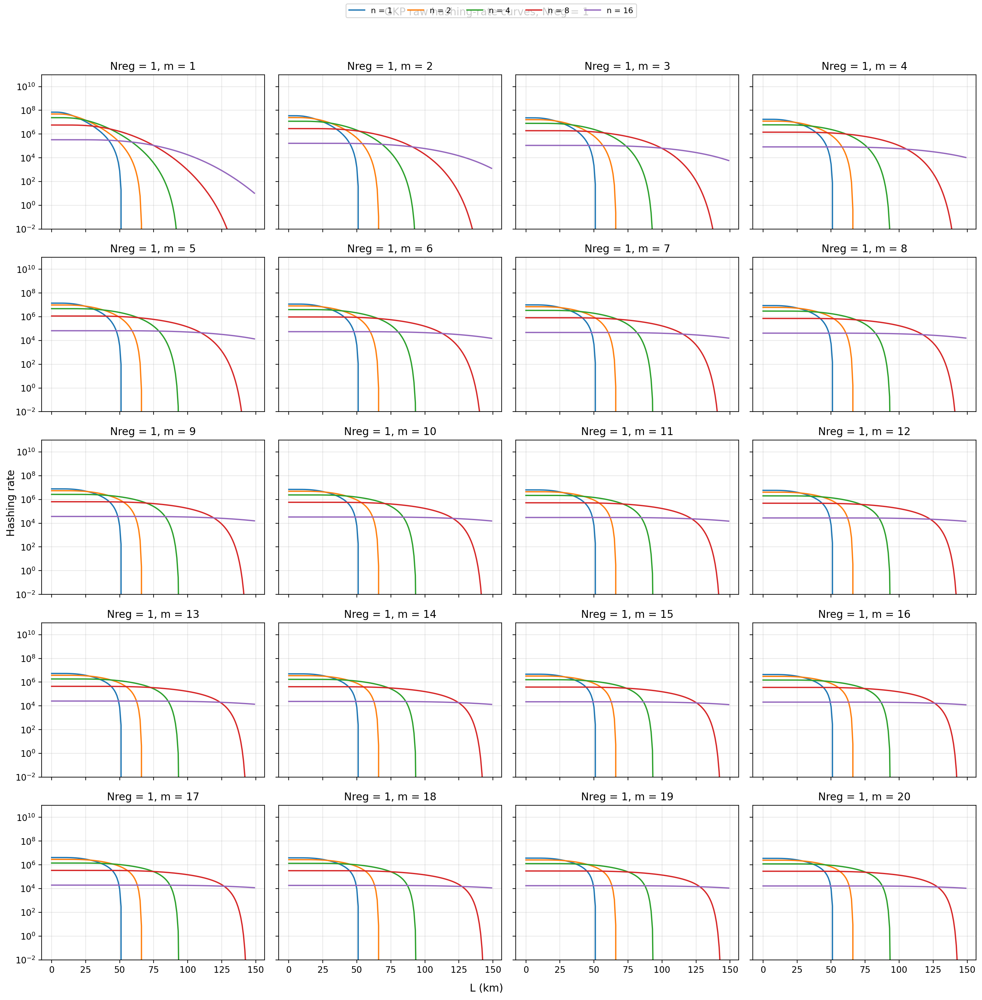


Plotting all m-plots for Nreg = 2


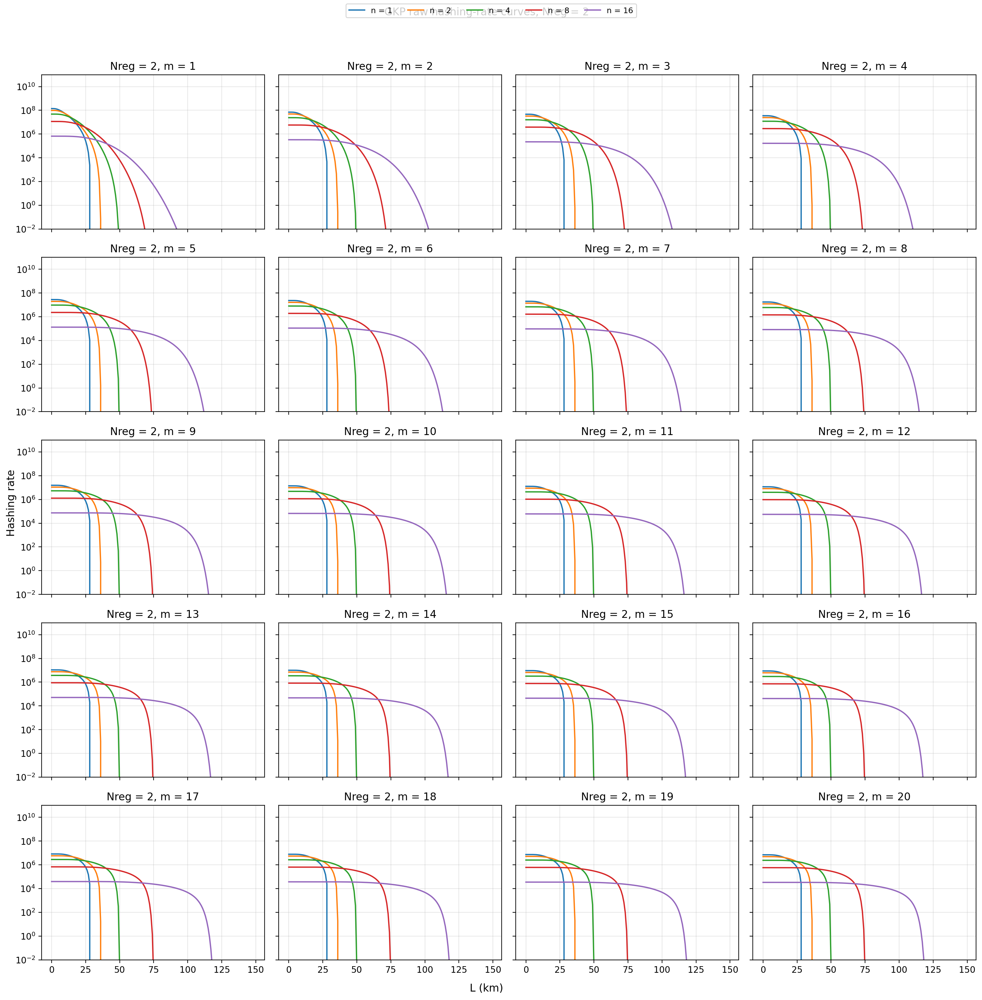


Plotting all m-plots for Nreg = 3


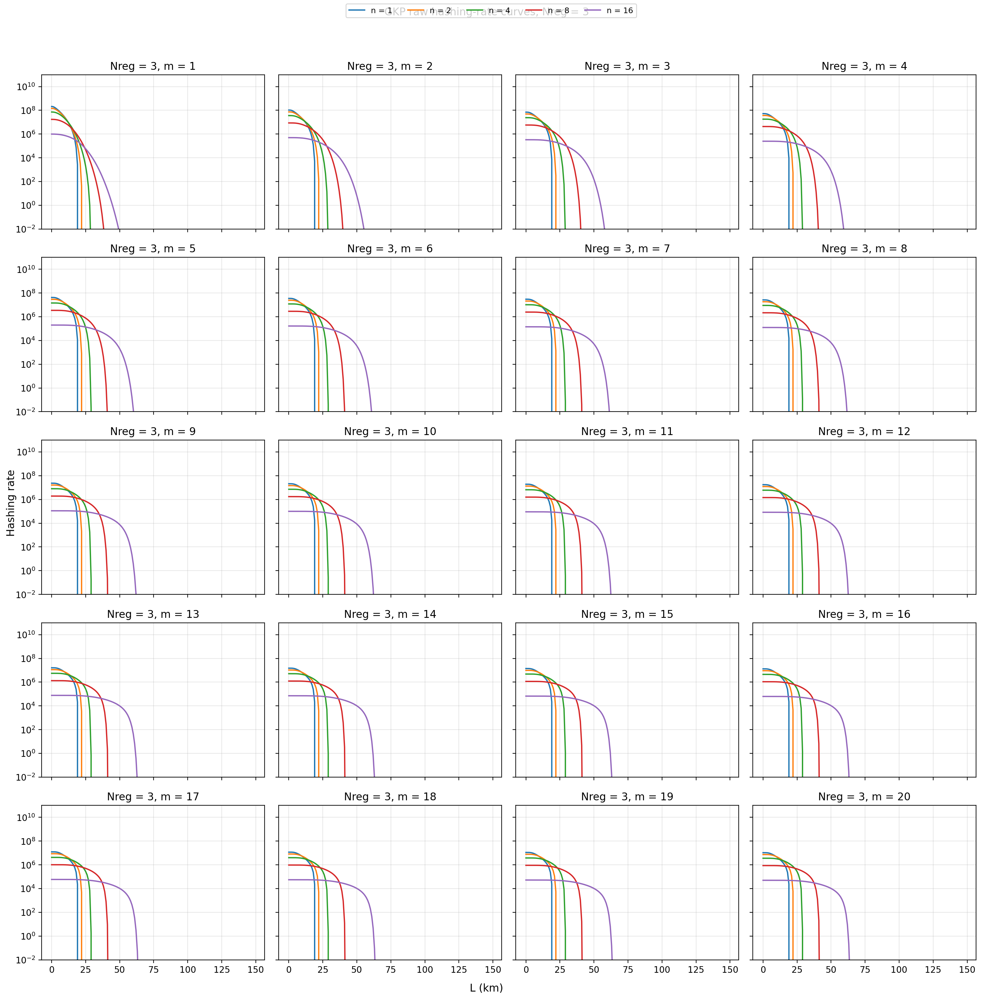


Plotting all m-plots for Nreg = 4


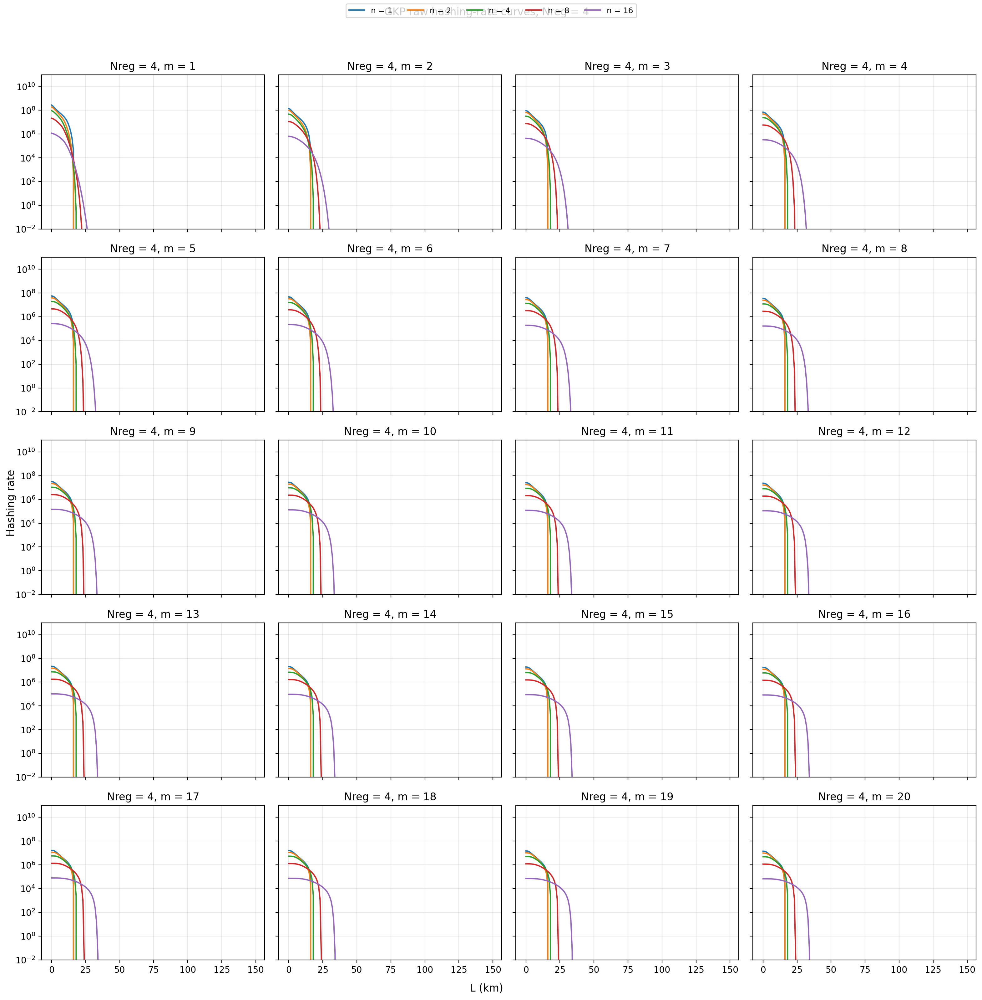


Done.


In [6]:
# ----------------------------
# Plot all 20 m-plots for each Nreg
# ----------------------------
for Nreg in Nreg_values:
    print(f"\nPlotting all m-plots for Nreg = {Nreg}")

    nplots = len(m_values)
    ncols = 4
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4 * ncols, 3.2 * nrows),
        dpi=200,
        sharex=True,
        sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    for idx, m in enumerate(m_values):
        ax = axes[idx]
        out = all_results[Nreg][m]

        for n in n_vals:
            ax.plot(
                out["Ls"],
                out["fixed_n_data"][n]["rate"],
                label=f"n = {n}"
            )

        ax.set_yscale("log")
        ax.set_ylim(bottom = 1e-2 , top = 1e11)
        ax.set_title(f"Nreg = {Nreg}, m = {m}")
        ax.grid(True, which="both", alpha=0.3)

    # turn off unused subplots
    for j in range(nplots, len(axes)):
        axes[j].axis("off")

    # one shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(n_vals), fontsize=9)

    fig.suptitle(f"GKP raw hashing-rate curves, Nreg = {Nreg}", y=0.995)
    fig.supxlabel("L (km)")
    fig.supylabel("Hashing rate")

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    fig_path = os.path.join(output_dir, f"gkp_raw_curves_Nreg_{Nreg}.png")
    plt.savefig(fig_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("\nDone.")

In [7]:
all_results = np.load(
    "gkp_raw_results.npy",
    allow_pickle=True
).item()

In [8]:
all_results

{1: {np.int64(1): {'Ls': array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
           11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
           22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
           33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
           44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
           55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
           66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
           77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
           88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
           99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
          110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
          121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
          132., 133., 134., 135., 136., 137., 138., 139., 140., 14

# Maximisation over HR curves


Plotting all available m-plots for Nreg = 1


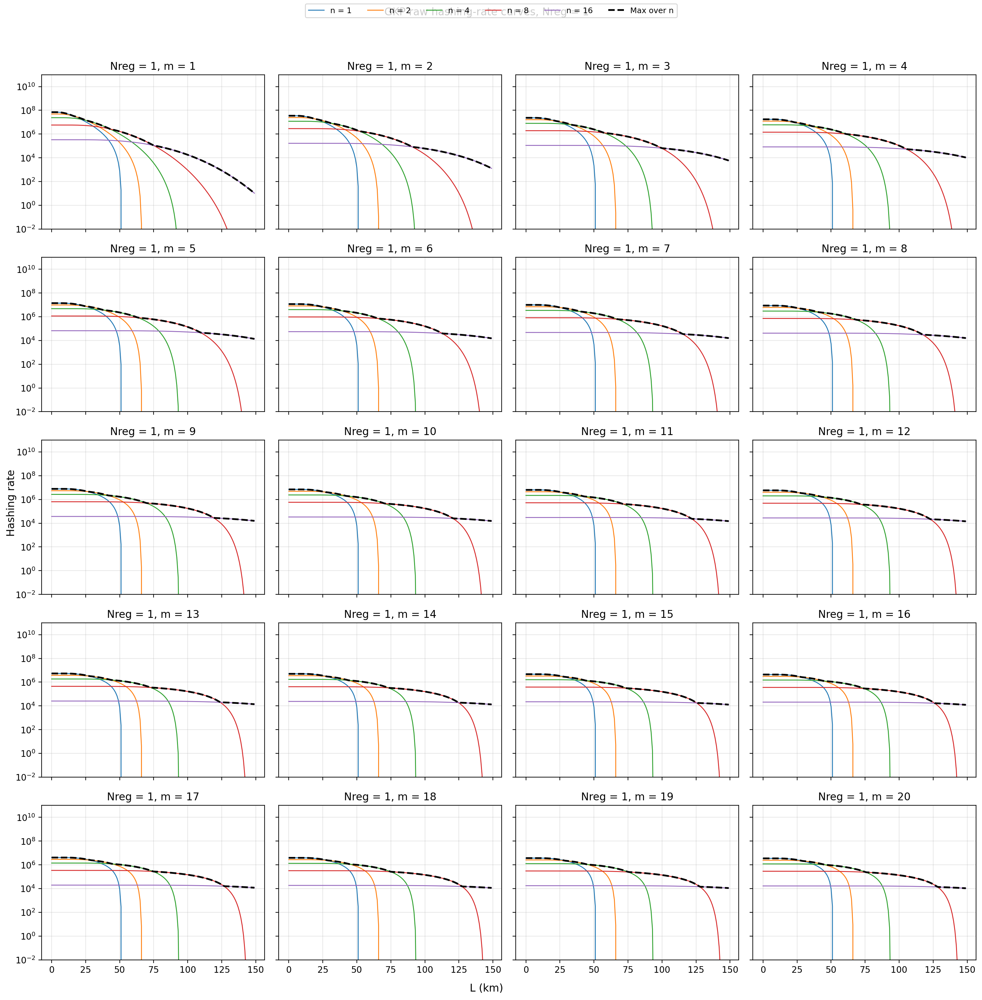


Plotting all available m-plots for Nreg = 2


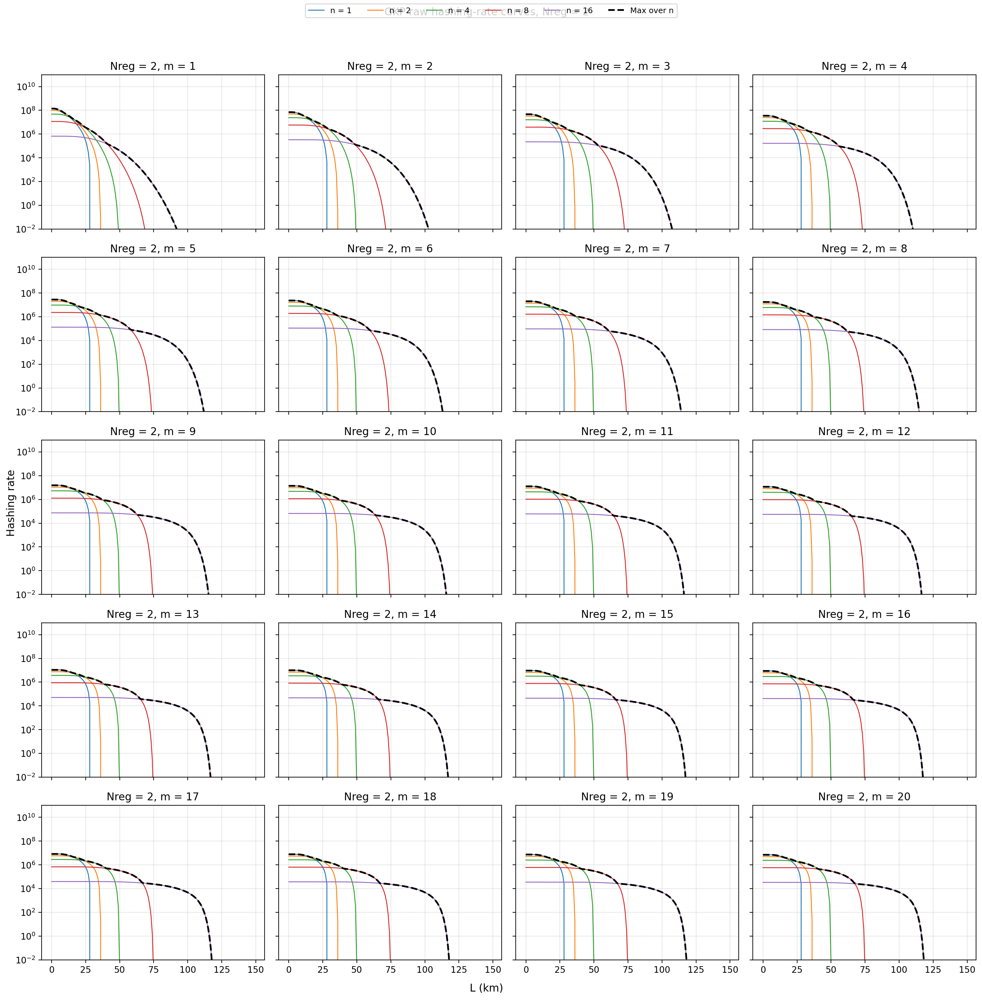


Plotting all available m-plots for Nreg = 3


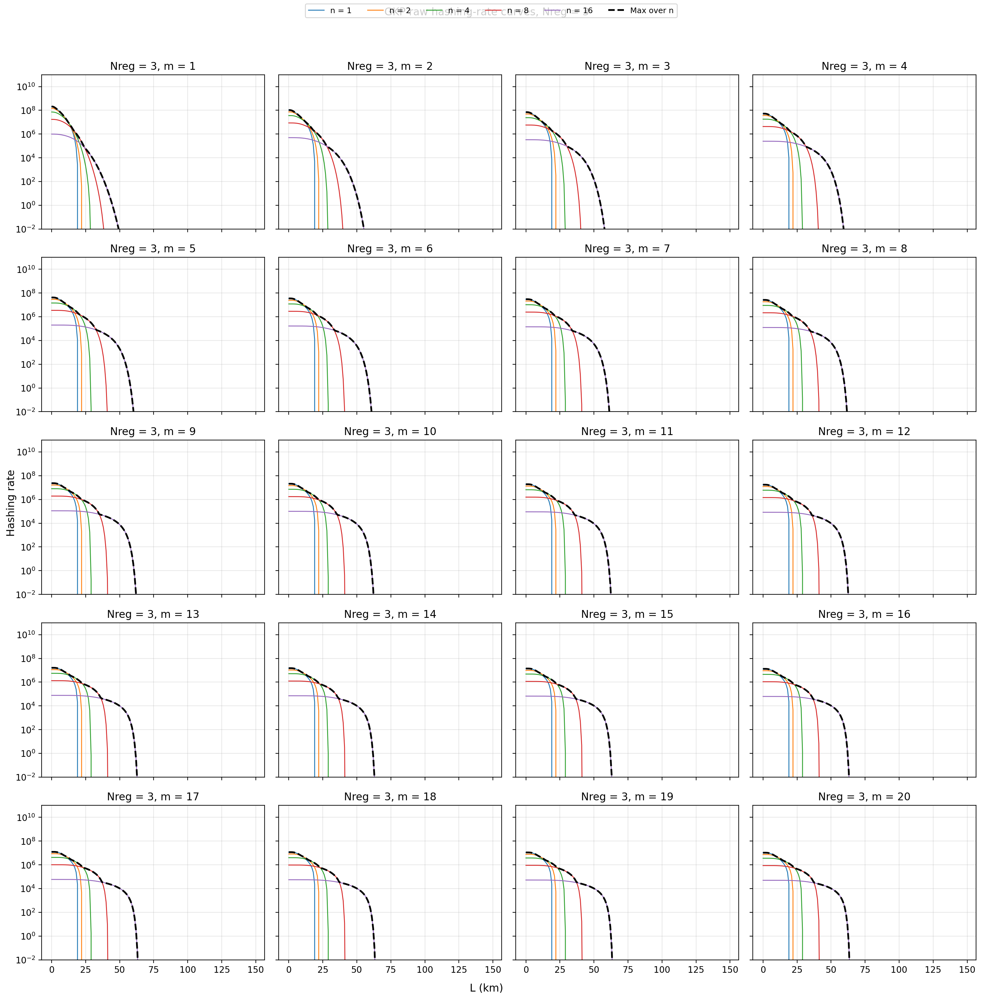


Plotting all available m-plots for Nreg = 4


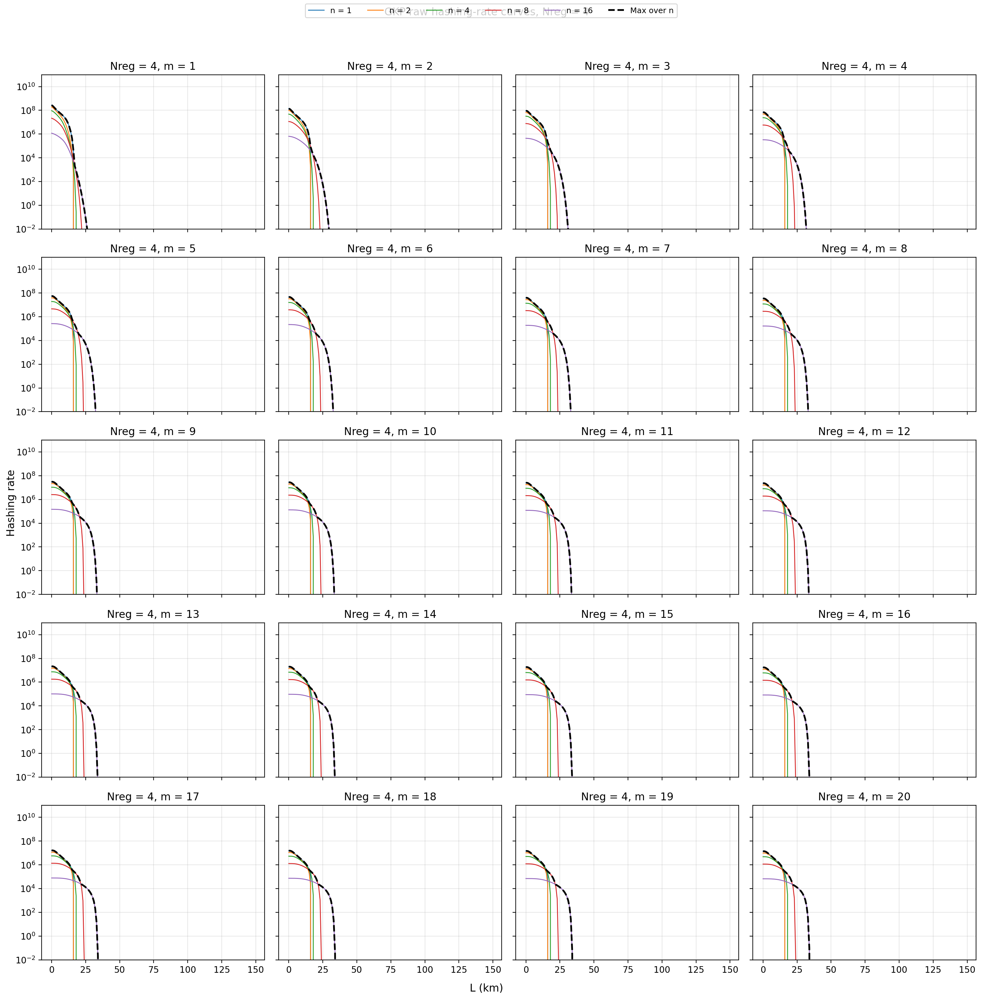


Done.


In [9]:
for Nreg in Nreg_values:

    print(f"\nPlotting all available m-plots for Nreg = {Nreg}")

    available_m = sorted(all_results[Nreg].keys())

    nplots = len(available_m)
    ncols = 4
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4 * ncols, 3.2 * nrows),
        dpi=200,
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes).reshape(-1)

    for idx, m in enumerate(available_m):

        ax = axes[idx]
        out = all_results[Nreg][m]

        fixed_n_curves = []

        for n in n_vals:

            curve = out["fixed_n_data"][n]["rate"]
            fixed_n_curves.append(curve)

            ax.plot(
                out["Ls"],
                curve,
                label=f"n = {n}",
                linewidth=1.0
            )

        fixed_n_curves = np.vstack(fixed_n_curves)

        maximisation_over_n_for_fixed_m = np.max(
            fixed_n_curves,
            axis=0
        )

        ax.plot(
            out["Ls"],
            maximisation_over_n_for_fixed_m,
            color="black",
            linestyle="--",
            linewidth=2,
            label="Max over n"
        )

        ax.set_yscale("log")
        ax.set_ylim(1e-2, 1e11)
        ax.set_title(f"Nreg = {Nreg}, m = {m}")
        ax.grid(True, which="both", alpha=0.3)

    # Turn off unused axes
    for j in range(nplots, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(n_vals) + 1,
        fontsize=9
    )

    fig.suptitle(
        f"GKP raw hashing-rate curves, Nreg = {Nreg}",
        y=0.995
    )

    fig.supxlabel("L (km)")
    fig.supylabel("Hashing rate")

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    fig_path = os.path.join(
        output_dir,
        f"gkp_raw_curves_with_envelope_Nreg_{Nreg}.png"
    )

    plt.savefig(
        fig_path,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

print("\nDone.")

# Linear Regression fits

In [10]:
import numpy as np
from scipy.stats import linregress


# ============================================================
# Count intersections between fitted line and a curve
# ============================================================

def count_curve_intersections(
    Ls,
    curve,
    slope,
    intercept,
    Lmin=None,
    Lmax=None,
    tolerance=1e-8
):
    """
    Count approximate intersections between

        log(curve)

    and

        slope * L + intercept.

    Intersections are detected from sign changes in the
    difference between the two curves in log-space.

    Parameters
    ----------
    Ls : array
        Distance values.

    curve : array
        Hashing-rate curve.

    slope, intercept : float
        Parameters of fitted log-linear model.

    Lmin, Lmax : float or None
        Optional range in which intersections are counted.

    tolerance : float
        Tolerance for near-zero differences.

    Returns
    -------
    count : int
        Number of approximate intersections.
    """

    Ls = np.asarray(Ls, dtype=float)
    curve = np.asarray(curve, dtype=float)

    mask = (
        np.isfinite(Ls)
        & np.isfinite(curve)
        & (curve > 0)
    )

    if Lmin is not None:
        mask &= Ls >= Lmin

    if Lmax is not None:
        mask &= Ls <= Lmax

    if np.sum(mask) < 2:
        return 0

    L = Ls[mask]
    log_curve = np.log(curve[mask])

    log_fit = slope * L + intercept

    difference = log_curve - log_fit

    # Exact/near intersections
    near_zero = np.abs(difference) < tolerance

    # Sign changes
    sign_change = (
        difference[:-1] * difference[1:] < 0
    )

    count = np.sum(sign_change)

    # Avoid counting a sign change and the same zero twice
    count += np.sum(near_zero)

    return int(count)


# ============================================================
# Automatic search for the best linear regression window
# ============================================================

def find_best_lr_window(
    Ls,
    envelope,
    fixed_n_curves=None,
    min_points=10,
    min_span=8.0,
    min_r2=0.995,
    max_rmse_log=0.10,
    require_all_intersections=False,
    intersection_range="global",
):
    """
    Automatically find the best linear-regression window for

        log(envelope) = slope * L + intercept.

    The search is performed over all contiguous windows.

    Selection philosophy:

    1. Window must contain enough points.
    2. Window must have sufficient physical length.
    3. The regression must have good R^2.
    4. The logarithmic residual must be small.
    5. Among acceptable windows, prefer the WIDEST window.
    6. Tie-break using R^2 and RMSE.
    7. Optionally require the fitted line to intersect all
       five fixed-n curves.

    Parameters
    ----------
    Ls : array
        Distance grid.

    envelope : array
        Max-over-n hashing-rate envelope.

    fixed_n_curves : dict or None
        Dictionary such as

            {
                1: curve_n1,
                2: curve_n2,
                4: curve_n4,
                8: curve_n8,
                16: curve_n16
            }

    min_points : int
        Minimum number of L points in a fitting interval.

    min_span : float
        Minimum physical L span in km.

    min_r2 : float
        Minimum acceptable R^2.

    max_rmse_log : float
        Maximum RMSE in natural-log space.

    require_all_intersections : bool
        If True, require the fitted line to intersect every
        fixed-n curve.

    intersection_range : {"global", "fit"}
        Range used for intersection counting.

    Returns
    -------
    result : dict
        Regression information and selected fitting interval.
    """

    Ls = np.asarray(Ls, dtype=float)
    envelope = np.asarray(envelope, dtype=float)

    valid = (
        np.isfinite(Ls)
        & np.isfinite(envelope)
        & (envelope > 0)
    )

    L = Ls[valid]
    R = envelope[valid]

    if len(L) < min_points:
        raise ValueError(
            "Not enough valid points for LR search."
        )

    log_R = np.log(R)

    candidate_results = []

    # --------------------------------------------------------
    # Search every contiguous interval
    # --------------------------------------------------------

    n = len(L)

    for i in range(n - min_points + 1):

        for j in range(i + min_points - 1, n):

            span = L[j] - L[i]

            if span < min_span:
                continue

            x = L[i:j + 1]
            y = log_R[i:j + 1]

            regression = linregress(x, y)

            slope = regression.slope
            intercept = regression.intercept
            r2 = regression.rvalue ** 2

            predicted = slope * x + intercept

            residuals = y - predicted

            rmse_log = np.sqrt(
                np.mean(residuals ** 2)
            )

            max_abs_residual = np.max(
                np.abs(residuals)
            )

            # ------------------------------------------------
            # Intersection diagnostic
            # ------------------------------------------------

            intersection_count = None

            if fixed_n_curves is not None:

                intersection_count = {}

                if intersection_range == "fit":
                    count_Lmin = L[i]
                    count_Lmax = L[j]
                else:
                    count_Lmin = L[0]
                    count_Lmax = L[-1]

                for n_value, curve in fixed_n_curves.items():

                    intersection_count[n_value] = (
                        count_curve_intersections(
                            Ls,
                            curve,
                            slope,
                            intercept,
                            Lmin=count_Lmin,
                            Lmax=count_Lmax,
                        )
                    )

            # ------------------------------------------------
            # Require all intersections if requested
            # ------------------------------------------------

            if require_all_intersections:

                if intersection_count is None:
                    raise ValueError(
                        "fixed_n_curves must be supplied when "
                        "require_all_intersections=True."
                    )

                if not all(
                    count >= 1
                    for count in intersection_count.values()
                ):
                    continue

            # ------------------------------------------------
            # Basic quality requirements
            # ------------------------------------------------

            if r2 < min_r2:
                continue

            if rmse_log > max_rmse_log:
                continue

            candidate_results.append({
                "i": i,
                "j": j,
                "L_min": L[i],
                "L_max": L[j],
                "span": span,
                "slope": slope,
                "intercept": intercept,
                "R_squared": r2,
                "RMSE_log": rmse_log,
                "max_abs_log_residual": max_abs_residual,
                "intersection_count": intersection_count,
            })

    # ========================================================
    # If acceptable windows exist, choose the widest one
    # ========================================================

    if candidate_results:

        # Sort:
        #
        # 1. widest fitting region
        # 2. highest R^2
        # 3. lowest RMSE
        #

        candidate_results.sort(
            key=lambda x: (
                x["span"],
                x["R_squared"],
                -x["RMSE_log"],
            ),
            reverse=True
        )

        best = candidate_results[0]

        return best

    # ========================================================
    # Fallback:
    # no window satisfied all thresholds
    #
    # In that case search again without hard R^2 / RMSE
    # rejection and choose the best compromise.
    # ========================================================

    fallback_results = []

    for i in range(n - min_points + 1):

        for j in range(i + min_points - 1, n):

            span = L[j] - L[i]

            if span < min_span:
                continue

            x = L[i:j + 1]
            y = log_R[i:j + 1]

            regression = linregress(x, y)

            slope = regression.slope
            intercept = regression.intercept
            r2 = regression.rvalue ** 2

            predicted = slope * x + intercept
            residuals = y - predicted

            rmse_log = np.sqrt(
                np.mean(residuals ** 2)
            )

            # ------------------------------------------------
            # Combined fallback score
            #
            # Strongly rewards linearity while also rewarding
            # a physically useful fitting interval.
            # ------------------------------------------------

            score = (
                r2
                - 0.50 * rmse_log
                + 0.001 * span
            )

            fallback_results.append({
                "i": i,
                "j": j,
                "L_min": L[i],
                "L_max": L[j],
                "span": span,
                "slope": slope,
                "intercept": intercept,
                "R_squared": r2,
                "RMSE_log": rmse_log,
                "max_abs_log_residual": np.max(
                    np.abs(residuals)
                ),
                "score": score,
            })

    if not fallback_results:
        raise ValueError(
            "Could not find a valid fitting window."
        )

    fallback_results.sort(
        key=lambda x: x["score"],
        reverse=True
    )

    return fallback_results[0]

In [11]:
# ============================================================
# Automatic LR fitting for every subplot
# ============================================================

lr_results = {}

for Nreg in Nreg_values:

    print(f"\nProcessing Nreg = {Nreg}")

    lr_results[Nreg] = {}

    available_m = sorted(all_results[Nreg].keys())

    for m in available_m:

        out = all_results[Nreg][m]

        Ls_plot = np.asarray(
            out["Ls"],
            dtype=float
        )

        # ----------------------------------------------------
        # Retrieve the five fixed-n curves
        # ----------------------------------------------------

        fixed_n_curves = {}

        for n in n_vals:
            fixed_n_curves[n] = np.asarray(
                out["fixed_n_data"][n]["rate"],
                dtype=float
            )

        # ----------------------------------------------------
        # Construct max-over-n envelope
        # ----------------------------------------------------

        stacked_curves = np.vstack([
            fixed_n_curves[n]
            for n in n_vals
        ])

        envelope = np.max(
            stacked_curves,
            axis=0
        )

        # ----------------------------------------------------
        # Find automatic fitting window
        # ----------------------------------------------------

        fit = find_best_lr_window(
            Ls_plot,
            envelope,
            fixed_n_curves=fixed_n_curves,

            # These are global safeguards rather than
            # physical fitting ranges.
            min_points=10,
            min_span=8.0,

            # Linearity requirements
            min_r2=0.995,
            max_rmse_log=0.10,

            # Start with this FALSE.
            #
            # We can turn it TRUE after seeing whether
            # demanding 5 intersections gives sensible
            # windows.
            require_all_intersections=False,

            intersection_range="global",
        )

        # ----------------------------------------------------
        # Fitted envelope
        # ----------------------------------------------------

        slope = fit["slope"]
        intercept = fit["intercept"]

        predicted_envelope = np.exp(
            intercept + slope * Ls_plot
        )

        # ----------------------------------------------------
        # Projected distances
        # ----------------------------------------------------

        if slope != 0:

            L_rate_1 = (
                np.log(1.0) - intercept
            ) / slope

            L_rate_1e2 = (
                np.log(1e-2) - intercept
            ) / slope

        else:

            L_rate_1 = np.nan
            L_rate_1e2 = np.nan

        # ----------------------------------------------------
        # Store everything
        # ----------------------------------------------------

        lr_results[Nreg][m] = {
            "slope": slope,
            "intercept": intercept,

            "R_squared": fit["R_squared"],
            "RMSE_log": fit["RMSE_log"],
            "max_abs_log_residual":
                fit["max_abs_log_residual"],

            "L_min": fit["L_min"],
            "L_max": fit["L_max"],
            "span": fit["span"],

            "envelope": envelope,
            "predicted_envelope":
                predicted_envelope,

            "L_rate_1": L_rate_1,
            "L_rate_1e2": L_rate_1e2,

            "intersection_count":
                fit.get("intersection_count", None),
        }

        print(
            f"Nreg={Nreg:>2}, "
            f"m={m:>2}: "
            f"Lfit = [{fit['L_min']:.2f}, "
            f"{fit['L_max']:.2f}] km, "
            f"span={fit['span']:.2f} km, "
            f"R²={fit['R_squared']:.6f}, "
            f"RMSE={fit['RMSE_log']:.5f}"
        )


Processing Nreg = 1
Nreg= 1, m= 1: Lfit = [11.00, 86.00] km, span=75.00 km, R²=0.997639, RMSE=0.09989
Nreg= 1, m= 2: Lfit = [6.00, 87.00] km, span=81.00 km, R²=0.996396, RMSE=0.09699
Nreg= 1, m= 3: Lfit = [7.00, 95.00] km, span=88.00 km, R²=0.995807, RMSE=0.09922
Nreg= 1, m= 4: Lfit = [7.00, 99.00] km, span=92.00 km, R²=0.995611, RMSE=0.09682
Nreg= 1, m= 5: Lfit = [8.00, 103.00] km, span=95.00 km, R²=0.995410, RMSE=0.09673
Nreg= 1, m= 6: Lfit = [9.00, 106.00] km, span=97.00 km, R²=0.995268, RMSE=0.09630
Nreg= 1, m= 7: Lfit = [9.00, 108.00] km, span=99.00 km, R²=0.995042, RMSE=0.09707
Nreg= 1, m= 8: Lfit = [10.00, 109.00] km, span=99.00 km, R²=0.995212, RMSE=0.09277
Nreg= 1, m= 9: Lfit = [10.00, 110.00] km, span=100.00 km, R²=0.995068, RMSE=0.09280
Nreg= 1, m=10: Lfit = [11.00, 111.00] km, span=100.00 km, R²=0.995050, RMSE=0.09138
Nreg= 1, m=11: Lfit = [13.00, 111.00] km, span=98.00 km, R²=0.995013, RMSE=0.08862
Nreg= 1, m=12: Lfit = [14.00, 68.00] km, span=54.00 km, R²=0.995359, RMSE=

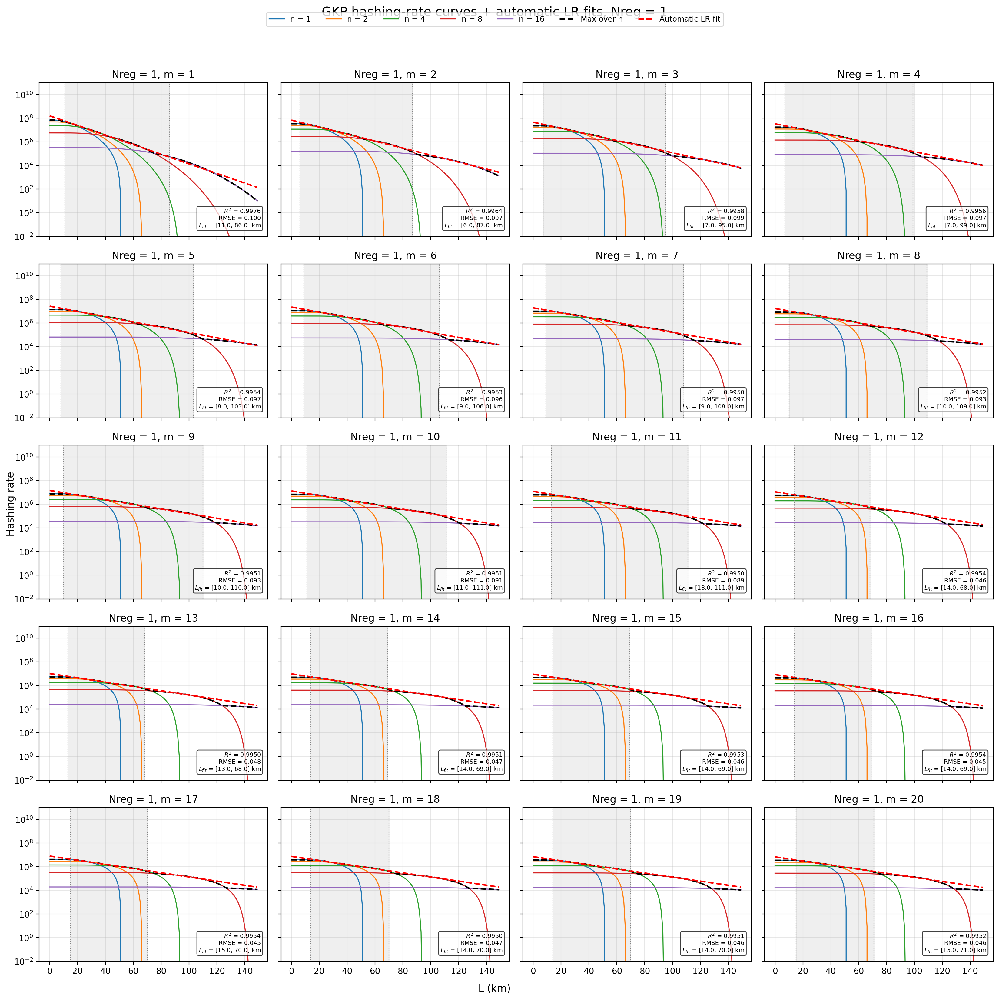

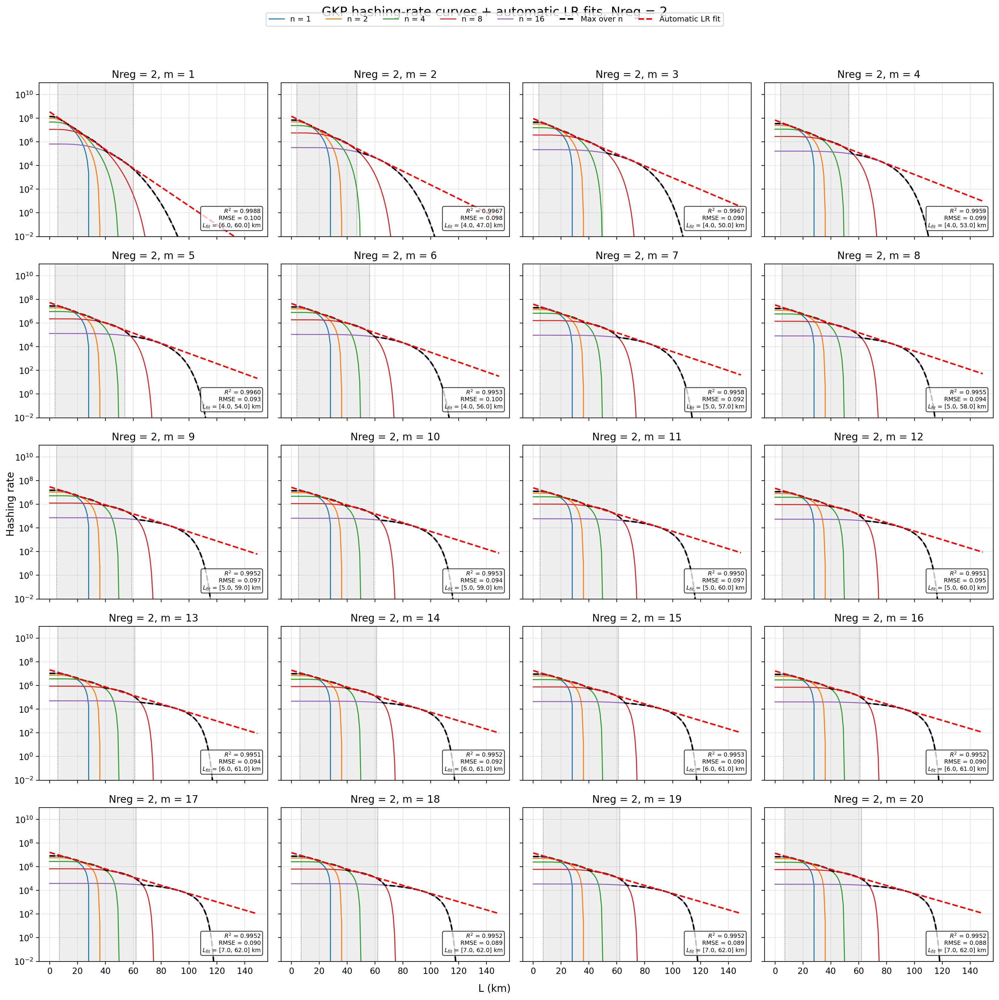

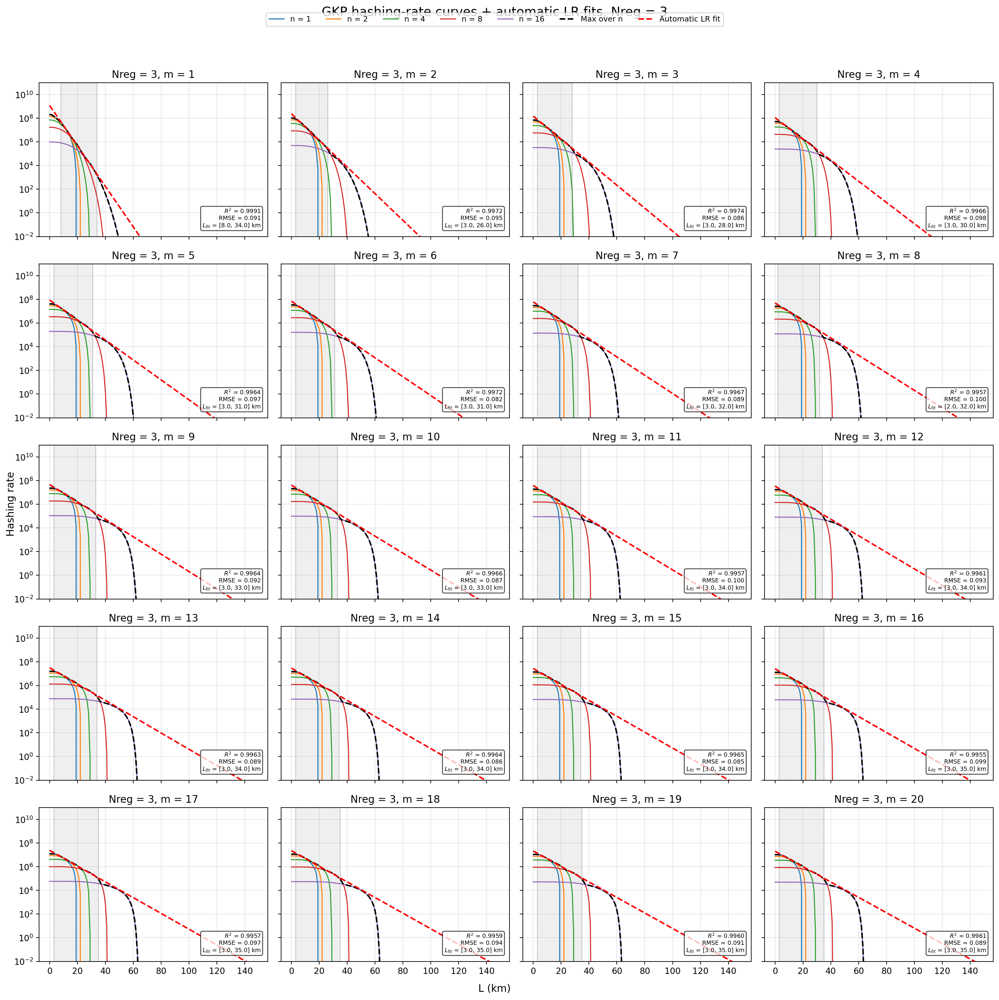

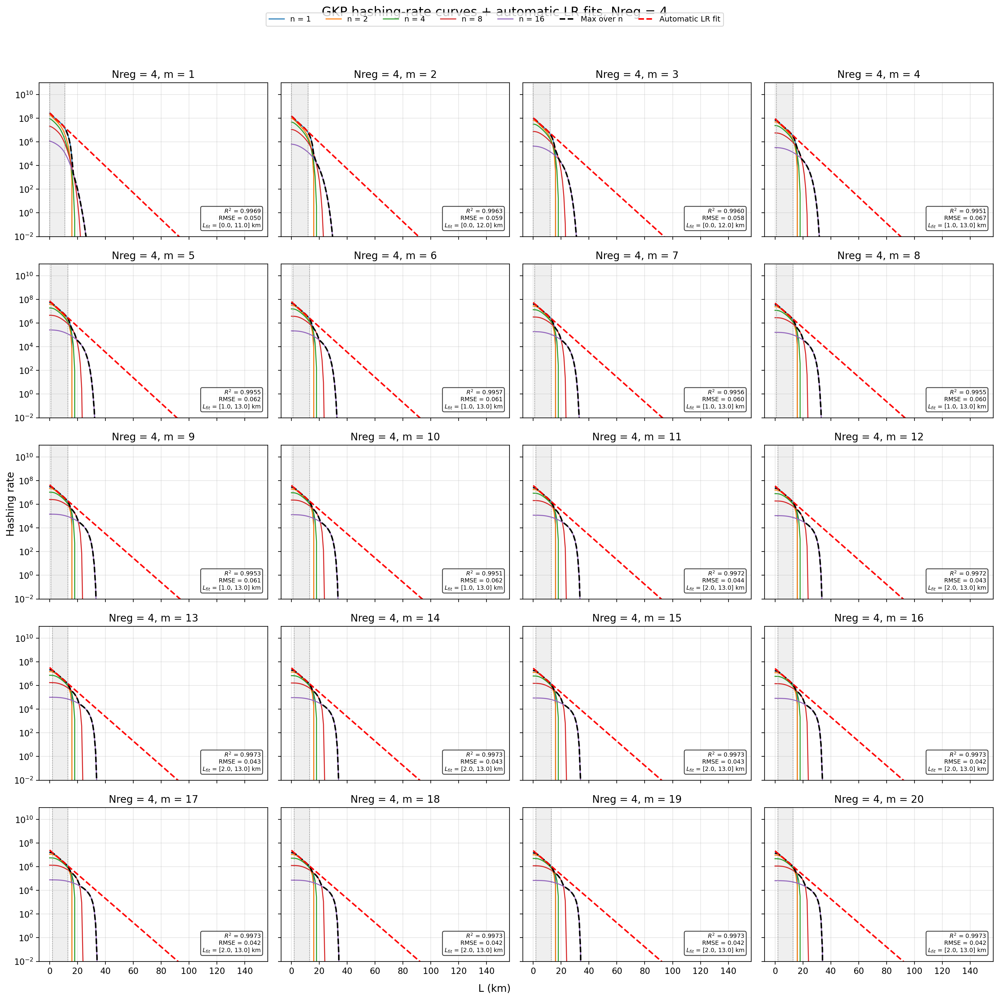

In [12]:
# ============================================================
# Plot automatically selected LR windows
# ============================================================

for Nreg in Nreg_values:

    nplots = len(available_m)
    ncols = 4
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.2 * ncols, 3.3 * nrows),
        dpi=200,
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes).reshape(-1)

    for idx, m in enumerate(available_m):

        ax = axes[idx]

        out = all_results[Nreg][m]
        fit = lr_results[Nreg][m]

        Ls_plot = out["Ls"]

        # ----------------------------------------------------
        # Plot fixed-n curves
        # ----------------------------------------------------

        for n in n_vals:

            ax.plot(
                Ls_plot,
                out["fixed_n_data"][n]["rate"],
                linewidth=1.2,
                label=f"n = {n}",
            )

        # ----------------------------------------------------
        # Envelope
        # ----------------------------------------------------

        ax.plot(
            Ls_plot,
            np.maximum(
                fit["envelope"],
                1e-30
            ),
            color="black",
            linestyle="--",
            linewidth=1.8,
            label="Max over n",
        )

        # ----------------------------------------------------
        # Automatic LR fit
        # ----------------------------------------------------

        ax.plot(
            Ls_plot,
            fit["predicted_envelope"],
            color="red",
            linestyle="--",
            linewidth=1.8,
            label="Automatic LR fit",
        )


        # ----------------------------------------------------
        # Show automatically selected fitting window
        # ----------------------------------------------------

        ax.axvspan(
            fit["L_min"],
            fit["L_max"],
            color="grey",
            alpha=0.12,
        )

        ax.axvline(
            fit["L_min"],
            color="grey",
            linestyle=":",
            linewidth=0.8,
        )

        ax.axvline(
            fit["L_max"],
            color="grey",
            linestyle=":",
            linewidth=0.8,
        )

        # ----------------------------------------------------
        # Put R² and RMSE in subplot
        # ----------------------------------------------------

        ax.text(
            0.97,
            0.05,
            (
                f"$R^2$ = {fit['R_squared']:.4f}\n"
                f"RMSE = {fit['RMSE_log']:.3f}\n"
                f"$L_{{fit}}$ = "
                f"[{fit['L_min']:.1f}, "
                f"{fit['L_max']:.1f}] km"
            ),
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=7,
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.75,
            ),
        )

        ax.set_yscale("log")
        ax.set_ylim(
            bottom=1e-2,
            top=1e11
        )

        ax.set_title(
            f"Nreg = {Nreg}, m = {m}"
        )

        ax.grid(
            True,
            which="both",
            alpha=0.3
        )

    # --------------------------------------------------------
    # Remove unused axes
    # --------------------------------------------------------

    for j in range(nplots, len(axes)):
        axes[j].axis("off")

    # --------------------------------------------------------
    # Shared legend
    # --------------------------------------------------------

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=7,
        fontsize=9,
        bbox_to_anchor=(0.5, 0.995),
    )

    fig.suptitle(
        f"GKP hashing-rate curves + automatic LR fits, "
        f"Nreg = {Nreg}",
        y=0.998,
        fontsize=15,
    )

    fig.supxlabel("L (km)")
    fig.supylabel("Hashing rate")

    plt.tight_layout(
        rect=[0, 0, 1, 0.965]
    )

    plt.show()
    plt.close(fig)

In [13]:
# ============================================================
# Attach LR information directly to all_results
# ============================================================

for Nreg in Nreg_values:

    for m in available_m:

        fit = lr_results[Nreg][m]

        all_results[Nreg][m]["lr_fit"] = {
            "slope": fit["slope"],
            "intercept": fit["intercept"],

            # Equation in log space:
            # ln(R) = slope * L + intercept
            "log_equation": (
                f"ln(R) = "
                f"({fit['slope']:.12e}) L + "
                f"({fit['intercept']:.12e})"
            ),

            # Equation in normal hashing-rate space:
            # R = exp(intercept + slope * L)
            "rate_equation": (
                f"R(L) = exp("
                f"({fit['slope']:.12e}) L + "
                f"({fit['intercept']:.12e})"
                f")"
            ),

            "L_min": fit["L_min"],
            "L_max": fit["L_max"],
            "span": fit["span"],

            "R_squared": fit["R_squared"],
            "RMSE_log": fit["RMSE_log"],
            "max_abs_log_residual":
                fit["max_abs_log_residual"],

            "L_rate_1": fit["L_rate_1"],
            "L_rate_1e2": fit["L_rate_1e2"],
        }


# ============================================================
# Save everything, including raw curves + LR fits
# ============================================================

np.save(
    "gkp_all_results_with_LR_fits.npy",
    all_results,
    allow_pickle=True
)

print(
    "Saved raw hashing-rate data and LR fits to "
    "gkp_all_results_with_LR_fits.npy"
)

Saved raw hashing-rate data and LR fits to gkp_all_results_with_LR_fits.npy


In [14]:
# ============================================================
# Construct LR curves for every Nreg and m
# ============================================================

lr_curves = {}

for Nreg in Nreg_values:

    lr_curves[Nreg] = {}

    for m in available_m:

        slope = all_results[Nreg][m]["lr_fit"]["slope"]
        intercept = all_results[Nreg][m]["lr_fit"]["intercept"]

        Ls_fit = all_results[Nreg][m]["Ls"]

        lr_curves[Nreg][m] = np.exp(
            intercept + slope * Ls_fit
        )

# Maximisation over m

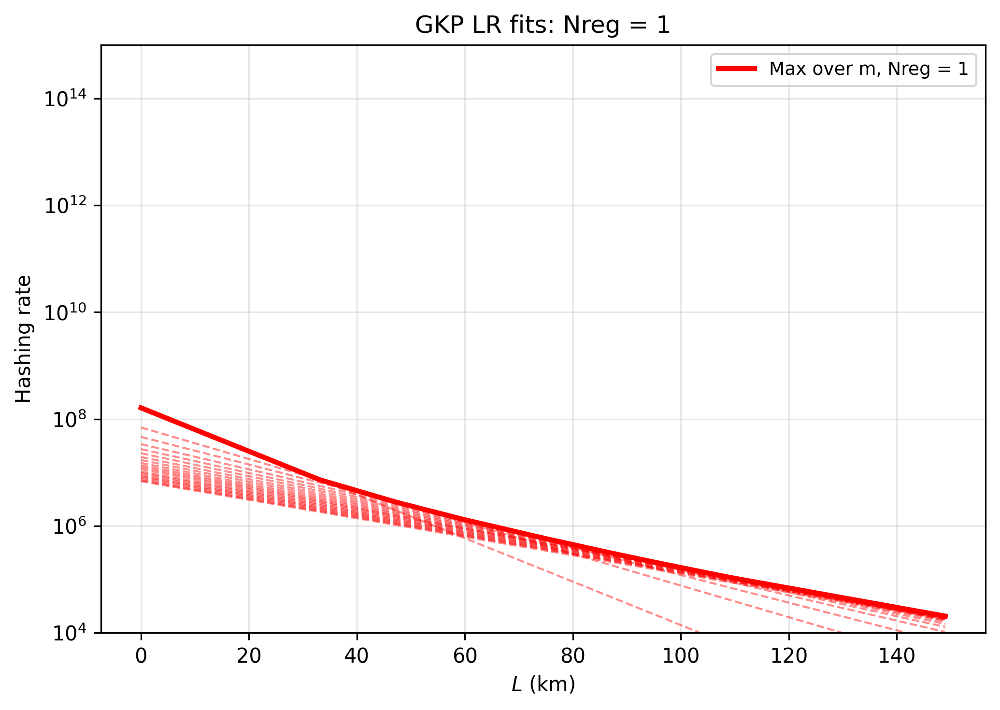

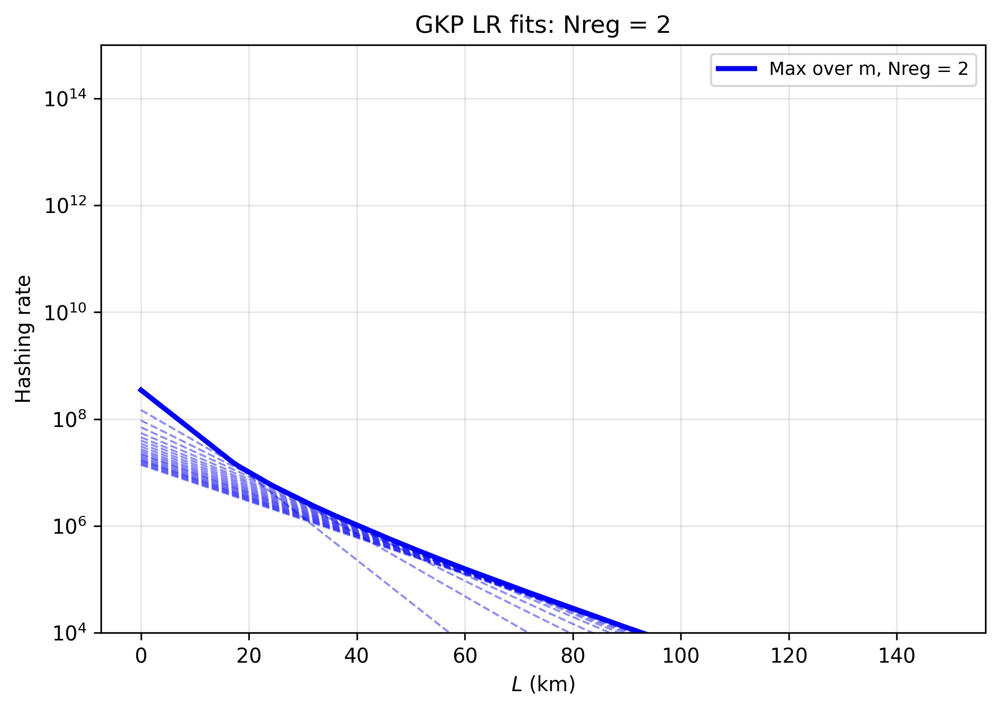

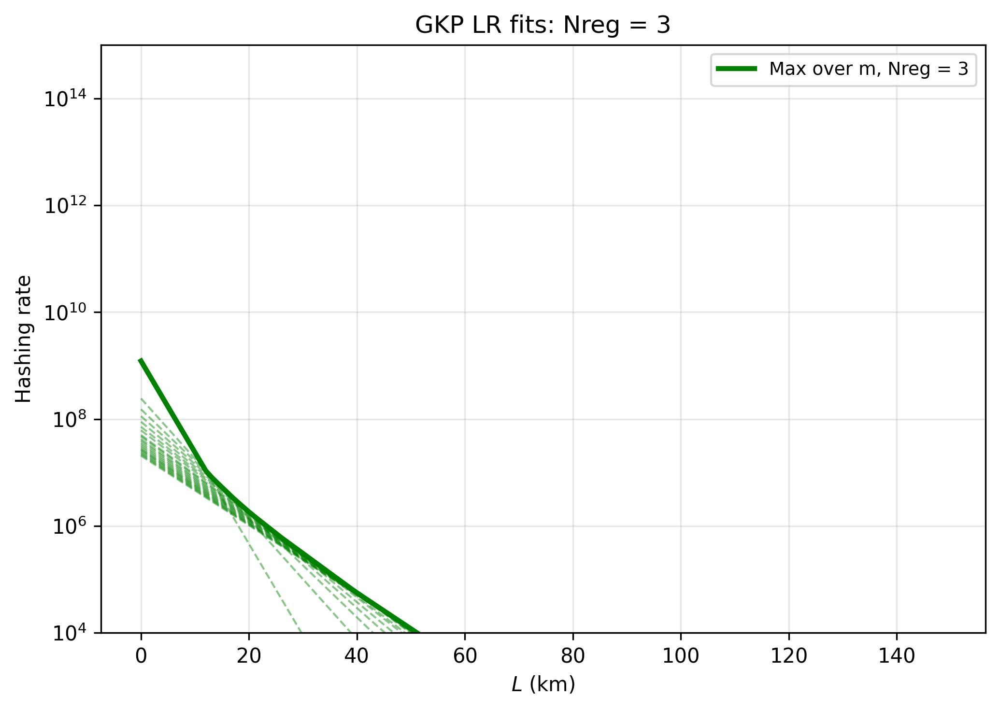

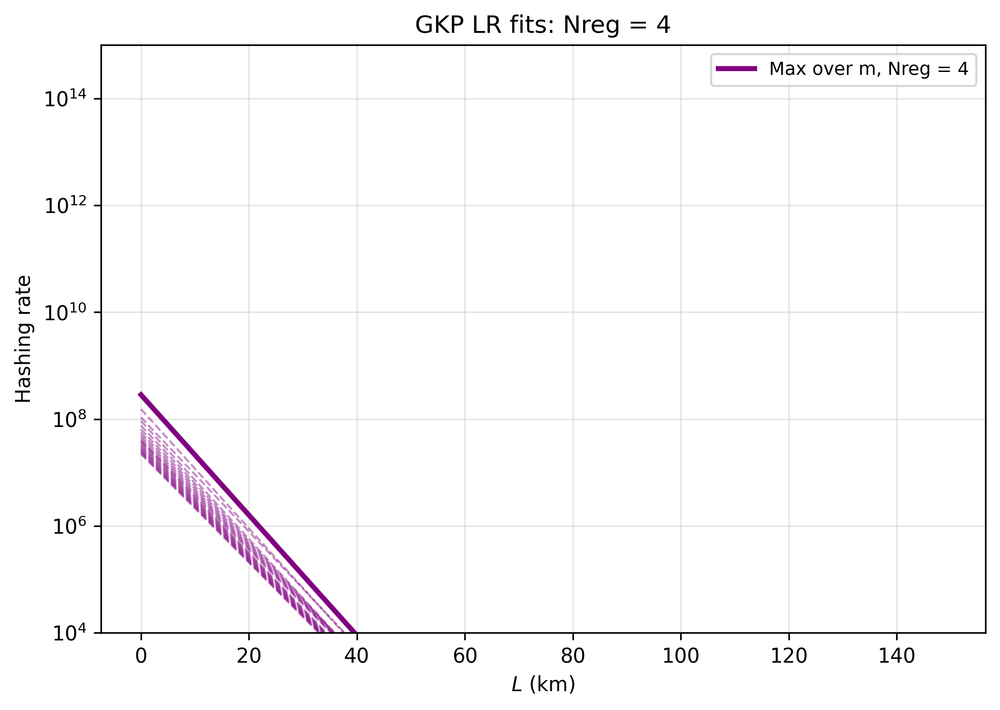

In [15]:
# ============================================================
# Maximise the LR fits over m for each Nreg
# ============================================================

lr_max_over_m = {}

for Nreg in Nreg_values:

    all_m_curves = np.vstack([
        lr_curves[Nreg][m]
        for m in available_m
    ])

    lr_max_over_m[Nreg] = np.max(
        all_m_curves,
        axis=0
    )


# ============================================================
# Plot all 20 LR fits for each Nreg
# ============================================================

Nreg_colours = {
    1: "red",
    2: "blue",
    3: "green",
    4: "purple",
}


for Nreg in Nreg_values:

    fig, ax = plt.subplots(
        figsize=(7, 5),
        dpi=300
    )

    colour = Nreg_colours[Nreg]

    # --------------------------------------------------------
    # Plot all 20 LR curves
    # --------------------------------------------------------

    for m in available_m:

        curve = lr_curves[Nreg][m]

        ax.plot(
            Ls,
            curve,
            color=colour,
            linestyle="--",
            linewidth=1.0,
            alpha=0.45,
        )

    # --------------------------------------------------------
    # Maximisation over m
    # --------------------------------------------------------

    ax.plot(
        Ls,
        lr_max_over_m[Nreg],
        color=colour,
        linestyle="-",
        linewidth=2.5,
        label=f"Max over m, Nreg = {Nreg}"
    )

    ax.set_yscale("log")

    ax.set_xlabel("$L$ (km)")
    ax.set_ylabel("Hashing rate")

    ax.set_ylim(bottom = 1e4 , top = 1e15)

    ax.set_title(
        f"GKP LR fits: Nreg = {Nreg}"
    )

    ax.grid(
        True,
        which="both",
        alpha=0.3
    )

    ax.legend(
        fontsize=9
    )

    plt.tight_layout()

    fig_path = os.path.join(
        output_dir,
        f"gkp_LR_all_m_Nreg_{Nreg}.png"
    )

    plt.savefig(
        fig_path,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

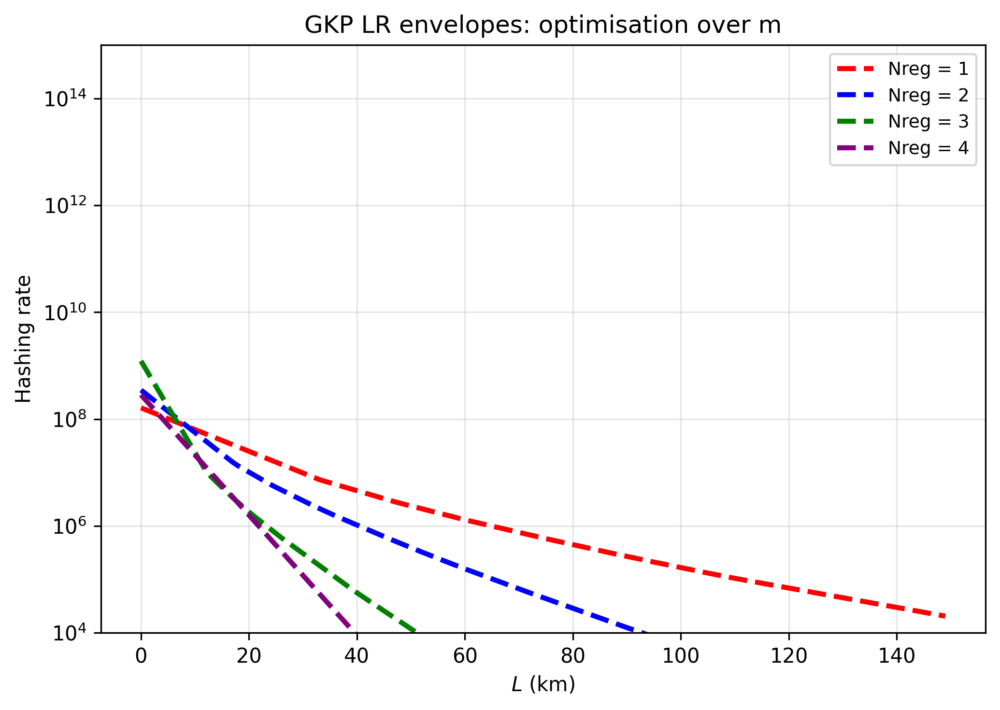

In [16]:
# ============================================================
# Plot maximised LR envelope for each Nreg
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5),
    dpi=300
)

for Nreg in Nreg_values:

    ax.plot(
        Ls,
        lr_max_over_m[Nreg],
        color=Nreg_colours[Nreg],
        linestyle="--",
        linewidth=2.5,
        label=f"Nreg = {Nreg}"
    )


ax.set_yscale("log")
ax.set_ylim(bottom = 1e4 , top = 1e15)
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")

ax.set_title(
    "GKP LR envelopes: optimisation over m"
)

ax.grid(
    True,
    which="both",
    alpha=0.3
)

ax.legend(
    fontsize=9
)

plt.tight_layout()

fig_path = os.path.join(
    output_dir,
    "gkp_LR_max_over_m_all_Nreg.png"
)

plt.savefig(
    fig_path,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

# PLOB

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_1468/629213588.py:7: RuntimeWarning: divide by zero encountered in log2
  return -np.log2(1 - eta) * (M / tau)


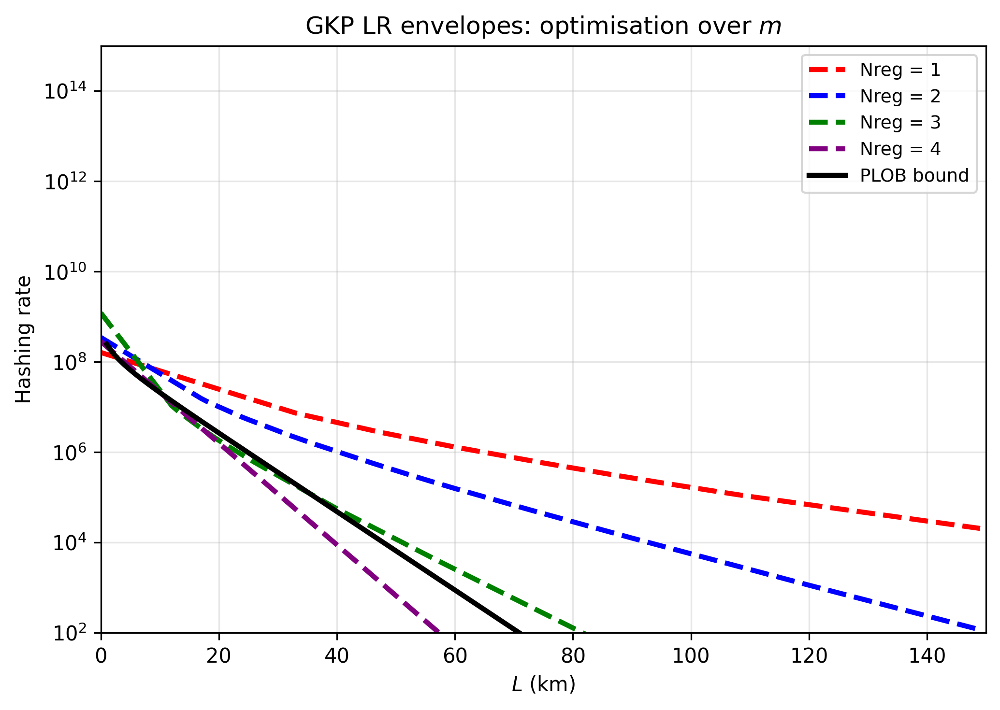

In [17]:
# ============================================================
# PLOB bound
# ============================================================

def PLOB_bound(L, alpha_dB_per_km=0.2 , M = 1 , tau = 1e-8):
    eta = np.exp(-alpha_dB_per_km * L)
    return -np.log2(1 - eta) * (M / tau)


# def PLOB_bound(L, alpha_dB_per_km=0.2, M=1, tau=1e-8):

#     eta = np.exp(-alpha_dB_per_km * L)

#     plob = -np.log2(1 - eta) * (M / tau)

#     # Represent the mathematical divergence at L = 0
#     if np.ndim(L) == 0:
#         if L == 0:
#             return 1e16
#         return plob

#     plob = np.asarray(plob, dtype=float)
#     plob[np.isclose(L, 0)] = 1e16

#     return plob


# ============================================================
# L grid
# ============================================================

Ls = np.arange(0, 150, 1.0)

PLOB_bound_tab = PLOB_bound(
    Ls,
    alpha_dB_per_km=0.2,
    M=M,
    tau=tau
)


# ============================================================
# Plot maximised LR envelope for each Nreg + PLOB
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5),
    dpi=300
)

# ------------------------------------------------------------
# Plot the four maximised LR envelopes
# ------------------------------------------------------------

for Nreg in Nreg_values:

    ax.plot(
        Ls,
        lr_max_over_m[Nreg],
        color=Nreg_colours[Nreg],
        linestyle="--",
        linewidth=2.5,
        label=f"Nreg = {Nreg}"
    )


# ------------------------------------------------------------
# Plot PLOB bound
# ------------------------------------------------------------

ax.plot(
    Ls,
    PLOB_bound_tab,
    color="black",
    linestyle="-",
    linewidth=2.5,
    label="PLOB bound"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_yscale("log")

ax.set_ylim(
    bottom=1e2,
    top=1e15
)

ax.set_xlim(
    left=0,
    right=150
)

ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")

ax.set_title(
    "GKP LR envelopes: optimisation over $m$"
)

ax.grid(
    True,
    which="both",
    alpha=0.3
)

ax.legend(
    fontsize=9
)

plt.tight_layout()


# ============================================================
# Save
# ============================================================

fig_path = os.path.join(
    output_dir,
    "gkp_LR_max_over_m_all_Nreg_with_PLOB.png"
)

plt.savefig(
    fig_path,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

# Qubit tools

In [18]:
def r(p, q):
    return np.array([
        p[3]*q[0] + p[2]*q[1] + p[1]*q[2] + p[0]*q[3],
        p[2]*q[0] + p[3]*q[1] + p[0]*q[2] + p[1]*q[3],
        p[1]*q[0] + p[0]*q[1] + p[3]*q[2] + p[2]*q[3],
        p[0]*q[0] + p[1]*q[1] + p[2]*q[2] + p[3]*q[3]
    ])

def rNtimes(p, n):
    if n == 1:
        return r(p, p)
    else:
        return r(rNtimes(p, n-1), p)

# transmissivity for QR setup
def new_eta(L, n):
    alpha_dB_per_km = 0.2
    alpha = (alpha_dB_per_km / 10) * np.log(10)  # convert dB/km to 1/km
    return np.exp(-alpha * L / (n + 1))  # eta ∈ [0, 1]

#von Neumann entropy
def vonneumann(mat):
    evals = eigvalsh(mat)
    evals = np.clip(evals, 1e-16 , 1)
    return -np.sum(evals * np.log2(evals))

# hashing bound
def hashing_bound(mat):
    sAB = vonneumann(mat)
    sA = vonneumann(dTraceSystem(mat , [2] , 2))
    sB = vonneumann(dTraceSystem(mat , [1] , 2))
    return max(sA - sAB , sB - sAB)

# chain function
def chain_function(vec , n):
    return rNtimes(vec , n)

# building the chain states
def BSM_mixture_chain(vec):
    return vec[0] * Phiplus + vec[1] * Phiminus + vec[2] * Psiplus + vec[3] * Psiminus

# Dual-Rail

In [19]:
# Dual Rail
def DualRailState(eta , Pd , Vis):
    return 4 * np.array(
        [
            [1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta), 0 , 0 , 0] ,
            [0 , 1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta) + 1/16 * ((1 - Pd)**4) * eta , 1/16 * ((1 - Pd)**4) * eta * Vis**2 , 0] ,
            [0 , 1/16 * ((1 - Pd)**4) *eta * Vis**2 , 1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta) + 1/16 * ((1 - Pd)**4) * eta , 0] ,
            [0 , 0 , 0 , 1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta)]
        ]
    )
# normalised quantum state for dual-rail entangled memory pair
def QStateDual(eta , Pd , Vis):
    state = DualRailState(eta , Pd , Vis)
    tr = np.trace(DualRailState(eta , Pd , Vis))
    # avoiding division by 0
    if tr == 0 or not np.isfinite(tr):
        return np.zeros_like(state)
    return state / tr

# hashing rate
def DRhashingrate(L , n , M , q , tau , m):
    eta = new_eta(L , n)
    PsuccDR = np.trace(DualRailState(eta , 0 , 1))

    # probability of BSM swap
    pSWAP = PsuccDR
    # probability single element success
    pELEM = 1 - (1 - pSWAP)**(M * m)
    # probability successful connection between end users
    pNETWORK = pELEM**(n + 1) * q**n
    # achievable rate of entanglement generation for the network
    rate = pNETWORK / (tau * m)

    if n == 1:
        return rate * hashing_bound(QStateDual(eta , 0 , 1))
    else:
        vec = rNtimes(np.linalg.eigvalsh(QStateDual(eta , 0 , 1)) , n - 1)
        rho = BSM_mixture_chain(vec)
        return rate * hashing_bound(rho)

In [20]:
def compute_dr_envelope_and_fit(Ls, n_scan_vals, M, q, tau, m, L_min=0, L_max=150):
    rate_envelope = []
    for L in Ls:
        best_rate = 0
        for n in n_scan_vals:
            try:
                rate = DRhashingrate(L, n, M, q, tau, m)
                if np.isfinite(rate):
                    best_rate = max(best_rate, rate)
            except:
                continue
        rate_envelope.append(best_rate)

    rate_env_arr = np.array(rate_envelope)
    valid_mask = (rate_env_arr > 0) & np.isfinite(rate_env_arr)
    fit_Ls = Ls[valid_mask]
    log_env = np.log(rate_env_arr[valid_mask])

    fit_mask = (fit_Ls > L_min) & (fit_Ls < L_max)
    slope, intercept, *_ = linregress(fit_Ls[fit_mask], log_env[fit_mask])
    predicted_env = np.exp(slope * Ls + intercept)

    return rate_env_arr, predicted_env

n_scan_vals = np.arange(1, 16)

dr_envelopes = []
rate_env, predicted_env = compute_dr_envelope_and_fit(Ls, n_scan_vals, M=1, q=0.7, tau=1e-8, m=1)
dr_envelopes.append(predicted_env)

In [21]:
Ls = np.arange(0 , 150 , 1.0)
n_scan_vals = np.arange(1, 16)

m_values = np.arange(1, 1000)

dr_envs = []

for m in m_values:
    print("Computing DR envelope for m =", m)
    _, predicted_env = compute_dr_envelope_and_fit(Ls,n_scan_vals,M=1,q=0.7,tau=1e-8,m=m)
    dr_envs.append(predicted_env)

Computing DR envelope for m = 1
Computing DR envelope for m = 2
Computing DR envelope for m = 3
Computing DR envelope for m = 4
Computing DR envelope for m = 5
Computing DR envelope for m = 6
Computing DR envelope for m = 7
Computing DR envelope for m = 8
Computing DR envelope for m = 9
Computing DR envelope for m = 10
Computing DR envelope for m = 11
Computing DR envelope for m = 12
Computing DR envelope for m = 13
Computing DR envelope for m = 14
Computing DR envelope for m = 15
Computing DR envelope for m = 16
Computing DR envelope for m = 17
Computing DR envelope for m = 18
Computing DR envelope for m = 19
Computing DR envelope for m = 20
Computing DR envelope for m = 21
Computing DR envelope for m = 22
Computing DR envelope for m = 23
Computing DR envelope for m = 24
Computing DR envelope for m = 25
Computing DR envelope for m = 26
Computing DR envelope for m = 27
Computing DR envelope for m = 28
Computing DR envelope for m = 29
Computing DR envelope for m = 30
Computing DR envelo

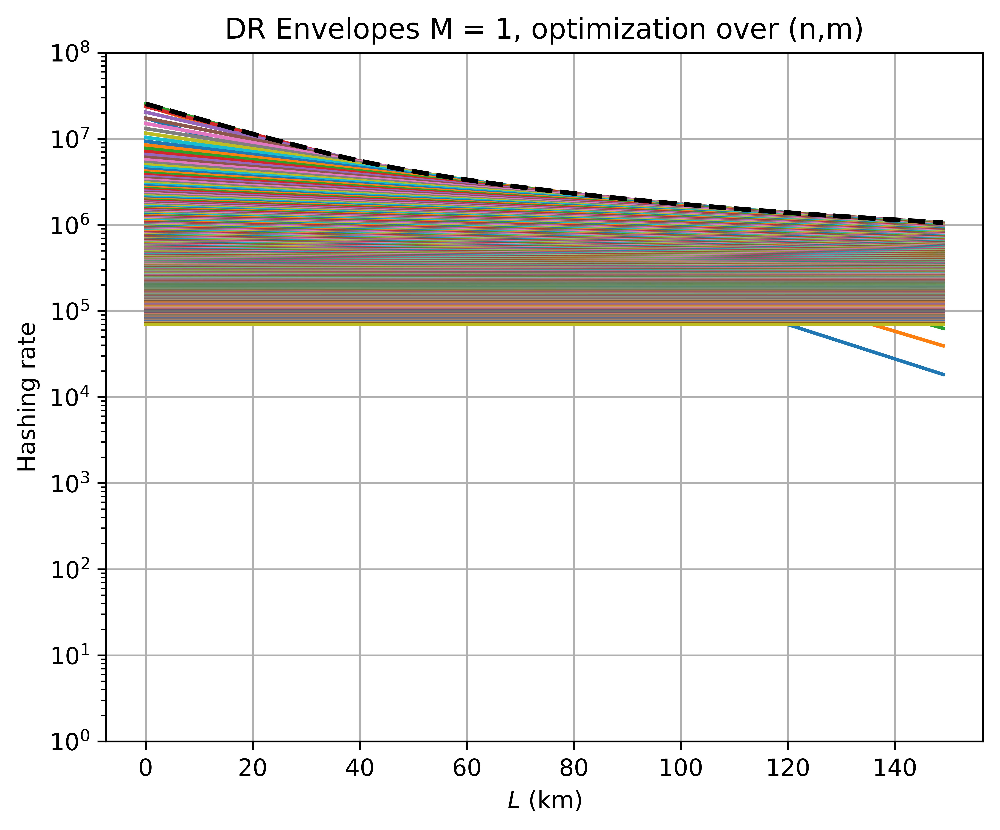

In [22]:
# dr_envs is already a list of arrays, one per m
env_matrix = np.array(dr_envs)  # shape: (len(m_values), len(Ls))
# fully maximized envelope over both n and m
fully_maximized_env = np.max(env_matrix, axis=0)


fig, ax = plt.subplots(figsize=(6,5), dpi=1000)

ax.set_yscale("log")
ax.set_title("DR Envelopes M = 1, optimization over (n,m)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.set_ylim(bottom=1e0, top=1e8)
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

# plot per-m envelopes
for i, env in enumerate(dr_envs):
    ax.plot(
        Ls,
        env,
        color=color_cycle(i % 10),
        linestyle="-",
        label=f"M = 1, m = {m_values[i]}"
    )

# plot fully maximized envelope
ax.plot(
    Ls,
    fully_maximized_env,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Maximized over n,m"
)

# ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

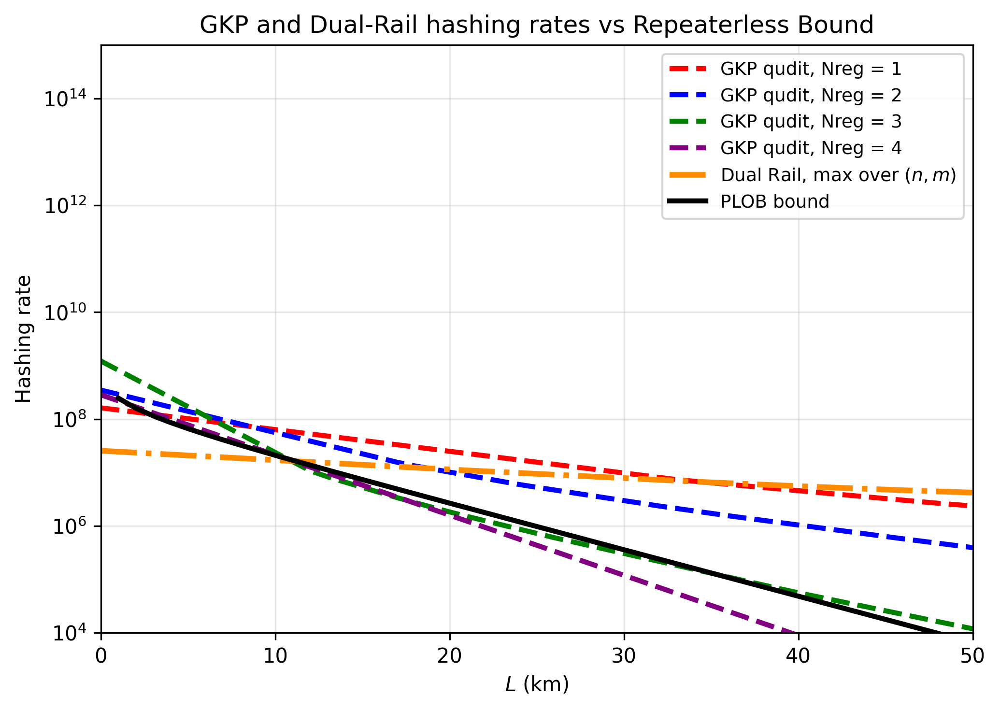

In [23]:
# ============================================================
# Combined GKP + Dual-Rail + PLOB plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5),
    dpi=300
)

# ------------------------------------------------------------
# GKP maximised LR envelopes over m
# ------------------------------------------------------------

for Nreg in Nreg_values:

    ax.plot(
        Ls,
        lr_max_over_m[Nreg],
        color=Nreg_colours[Nreg],
        linestyle="--",
        linewidth=2.5,
        label=f"GKP qudit, Nreg = {Nreg}"
    )


# ------------------------------------------------------------
# Dual-Rail fully maximised envelope
# ------------------------------------------------------------
#
# fully_maximized_env is already:
#
#   max over n and m
#
# ------------------------------------------------------------

ax.plot(
    Ls,
    fully_maximized_env,
    color="darkorange",
    linestyle="-.",
    linewidth=2.8,
    label="Dual Rail, max over $(n,m)$"
)


# ------------------------------------------------------------
# PLOB bound
# ------------------------------------------------------------

ax.plot(
    Ls,
    PLOB_bound_tab,
    color="black",
    linestyle="-",
    linewidth=2.5,
    label="PLOB bound"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_yscale("log")

ax.set_ylim(
    bottom=1e4,
    top=1e15
)

ax.set_xlim(
    left=0,
    right=50
)

ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")

ax.set_title(
    "GKP and Dual-Rail hashing rates vs Repeaterless Bound"
)

ax.grid(
    True,
    which="both",
    alpha=0.3
)

ax.legend(
    fontsize=9
)

plt.tight_layout()


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

fig_path = os.path.join(
    output_dir,
    "gkp_vs_dualrail_vs_PLOB.png"
)

plt.savefig(
    fig_path,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

# Inset

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_1468/1366748305.py:230: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


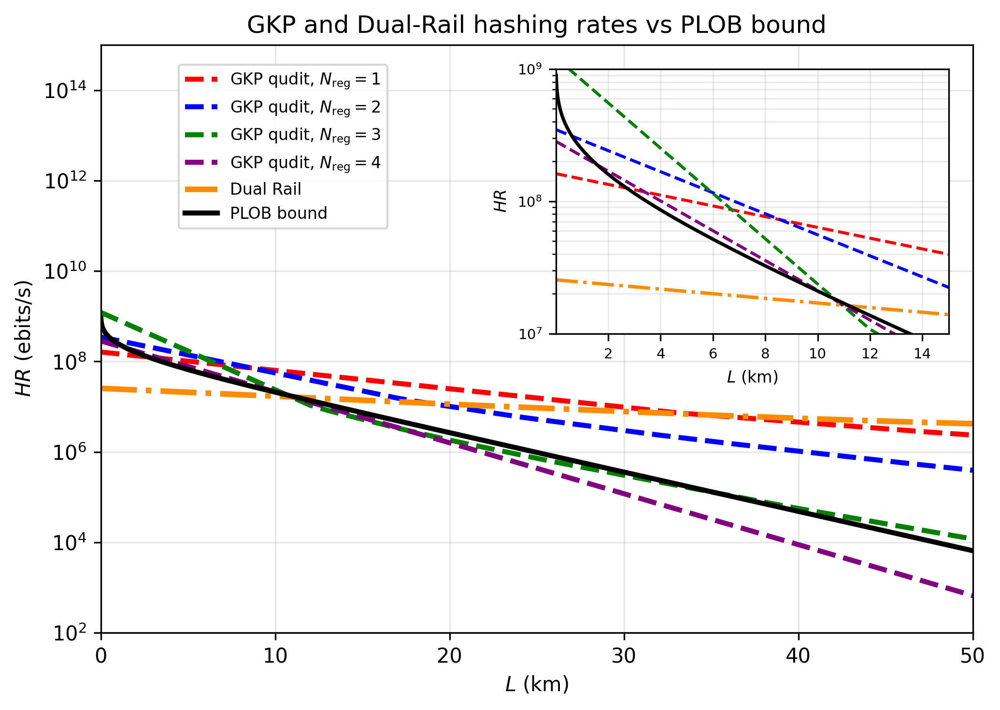

In [24]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ============================================================
# PLOB bound
# ============================================================

def PLOB_bound(L, alpha_dB_per_km=0.2, M=1, tau=1e-8):
    eta = np.exp(-alpha_dB_per_km * L)
    return -np.log2(1 - eta) * (M / tau)


# ============================================================
# Distance grids
# ============================================================

# Existing grid used for the GKP and dual-rail results
Ls = np.arange(0, 150, 1.0)

# Fine grid for PLOB so the L -> 0 behaviour is resolved
Ls_plob = np.arange(0.01, 150.01, 0.01)

# Fine grid specifically for the inset
Ls_zoom = np.arange(0.01, 15.01, 0.01)


# ============================================================
# PLOB values
# ============================================================

PLOB_bound_tab = PLOB_bound(
    Ls_plob,
    alpha_dB_per_km=0.2,
    M=M,
    tau=tau
)

PLOB_bound_zoom = PLOB_bound(
    Ls_zoom,
    alpha_dB_per_km=0.2,
    M=M,
    tau=tau
)


# ============================================================
# Combined GKP + Dual-Rail + PLOB plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5),
    dpi=300
)


# ------------------------------------------------------------
# Main plot: GKP maximised envelopes
# ------------------------------------------------------------

for Nreg in Nreg_values:
    ax.plot(
        Ls,
        lr_max_over_m[Nreg],
        color=Nreg_colours[Nreg],
        linestyle="--",
        linewidth=2.5,
        label=f"GKP qudit, $N_{{\\rm reg}}={Nreg}$"
    )


# ------------------------------------------------------------
# Main plot: Dual-Rail maximised envelope
# ------------------------------------------------------------

ax.plot(
    Ls,
    fully_maximized_env,
    color="darkorange",
    linestyle="-.",
    linewidth=2.8,
    label="Dual Rail"
)


# ------------------------------------------------------------
# Main plot: PLOB
# ------------------------------------------------------------

ax.plot(
    Ls_plob,
    PLOB_bound_tab,
    color="black",
    linestyle="-",
    linewidth=2.5,
    label="PLOB bound"
)


# ------------------------------------------------------------
# Main formatting
# ------------------------------------------------------------

ax.set_yscale("log")

ax.set_ylim(
    bottom=1e2,
    top=1e15
)

ax.set_xlim(
    left=0,
    right=50
)

ax.set_xlabel("$L$ (km)")
ax.set_ylabel("$HR$ (ebits/s)")

ax.set_title(
    "GKP and Dual-Rail hashing rates vs PLOB bound"
)

ax.grid(
    True,
    which="both",
    alpha=0.3
)

ax.legend(
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(0.08, 0.98),
    frameon=True
)


# ============================================================
# Inset: L = 0.01--15 km
# ============================================================

axins = inset_axes(
    ax,
    width="45%",
    height="45%",
    loc="upper right",
    borderpad=1.2
)


# ------------------------------------------------------------
# GKP curves in inset
# ------------------------------------------------------------

for Nreg in Nreg_values:
    axins.plot(
        Ls,
        lr_max_over_m[Nreg],
        color=Nreg_colours[Nreg],
        linestyle="--",
        linewidth=1.5
    )


# ------------------------------------------------------------
# Dual-Rail curve in inset
# ------------------------------------------------------------

axins.plot(
    Ls,
    fully_maximized_env,
    color="darkorange",
    linestyle="-.",
    linewidth=1.7
)


# ------------------------------------------------------------
# PLOB curve in inset
# ------------------------------------------------------------

axins.plot(
    Ls_zoom,
    PLOB_bound_zoom,
    color="black",
    linestyle="-",
    linewidth=1.7
)


# ------------------------------------------------------------
# Inset formatting
# ------------------------------------------------------------

axins.set_yscale("log")

axins.set_xlim(
    0.01,
    15
)

axins.set_ylim(
    1e7,
    1e9
)

axins.set_xlabel(
    "$L$ (km)",
    fontsize=8
)

axins.set_ylabel(
    "$HR$",
    fontsize=8
)

axins.tick_params(
    axis="both",
    labelsize=7
)

axins.grid(
    True,
    which="both",
    alpha=0.25
)


# ============================================================
# Save and display
# ============================================================

plt.tight_layout()

fig_path = os.path.join(
    output_dir,
    "gkp_vs_dualrail_vs_PLOB_with_inset.png"
)

plt.savefig(
    fig_path,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

# Omitting Nreg=4

In [25]:
Nreg_values_alt = [1,2,3]

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_1468/812776981.py:230: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


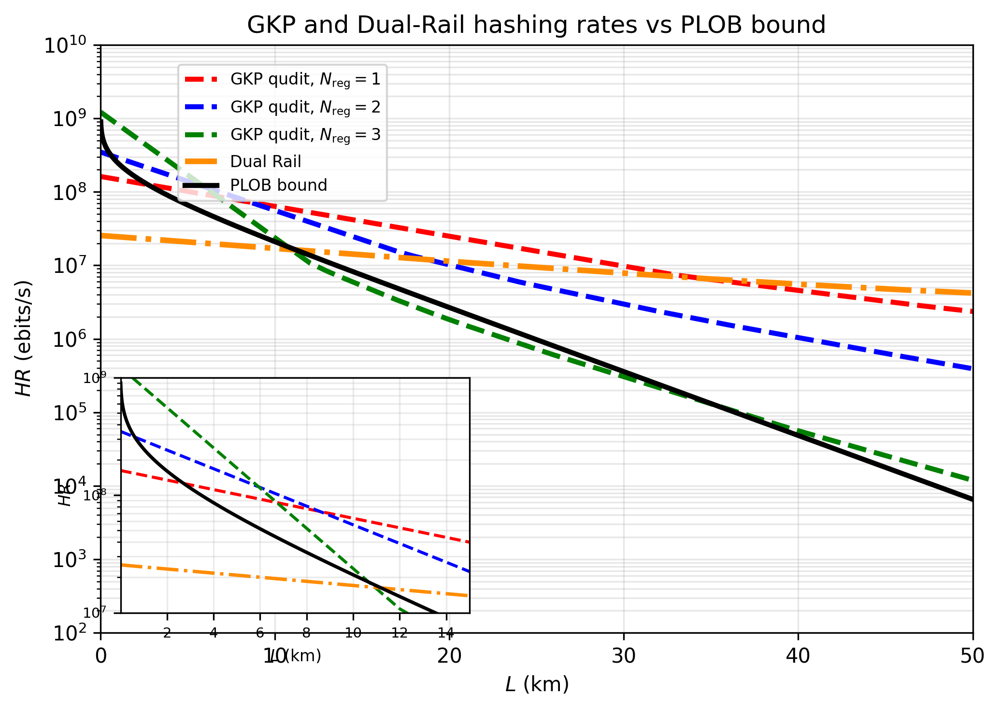

In [31]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ============================================================
# PLOB bound
# ============================================================

def PLOB_bound(L, alpha_dB_per_km=0.2, M=1, tau=1e-8):
    eta = np.exp(-alpha_dB_per_km * L)
    return -np.log2(1 - eta) * (M / tau)


# ============================================================
# Distance grids
# ============================================================

# Existing grid used for the GKP and dual-rail results
Ls = np.arange(0, 150, 1.0)

# Fine grid for PLOB so the L -> 0 behaviour is resolved
Ls_plob = np.arange(0.01, 150.01, 0.01)

# Fine grid specifically for the inset
Ls_zoom = np.arange(0.01, 15.01, 0.01)


# ============================================================
# PLOB values
# ============================================================

PLOB_bound_tab = PLOB_bound(
    Ls_plob,
    alpha_dB_per_km=0.2,
    M=M,
    tau=tau
)

PLOB_bound_zoom = PLOB_bound(
    Ls_zoom,
    alpha_dB_per_km=0.2,
    M=M,
    tau=tau
)


# ============================================================
# Combined GKP + Dual-Rail + PLOB plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5),
    dpi=300
)


# ------------------------------------------------------------
# Main plot: GKP maximised envelopes
# ------------------------------------------------------------

for Nreg in Nreg_values_alt:
    ax.plot(
        Ls,
        lr_max_over_m[Nreg],
        color=Nreg_colours[Nreg],
        linestyle="--",
        linewidth=2.5,
        label=f"GKP qudit, $N_{{\\rm reg}}={Nreg}$"
    )


# ------------------------------------------------------------
# Main plot: Dual-Rail maximised envelope
# ------------------------------------------------------------

ax.plot(
    Ls,
    fully_maximized_env,
    color="darkorange",
    linestyle="-.",
    linewidth=2.8,
    label="Dual Rail"
)


# ------------------------------------------------------------
# Main plot: PLOB
# ------------------------------------------------------------

ax.plot(
    Ls_plob,
    PLOB_bound_tab,
    color="black",
    linestyle="-",
    linewidth=2.5,
    label="PLOB bound"
)


# ------------------------------------------------------------
# Main formatting
# ------------------------------------------------------------

ax.set_yscale("log")

ax.set_ylim(
    bottom=1e2,
    top=1e10
)

ax.set_xlim(
    left=0,
    right=50
)

ax.set_xlabel("$L$ (km)")
ax.set_ylabel("$HR$ (ebits/s)")

ax.set_title(
    "GKP and Dual-Rail hashing rates vs PLOB bound"
)

ax.grid(
    True,
    which="both",
    alpha=0.3
)

ax.legend(
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(0.08, 0.98),
    frameon=True
)


# ============================================================
# Inset: L = 0.01--15 km
# ============================================================

axins = inset_axes(
    ax,
    width="40%",
    height="40%",
    loc="lower left",
    borderpad=1.0
)


# ------------------------------------------------------------
# GKP curves in inset
# ------------------------------------------------------------

for Nreg in Nreg_values_alt:
    axins.plot(
        Ls,
        lr_max_over_m[Nreg],
        color=Nreg_colours[Nreg],
        linestyle="--",
        linewidth=1.5
    )


# ------------------------------------------------------------
# Dual-Rail curve in inset
# ------------------------------------------------------------

axins.plot(
    Ls,
    fully_maximized_env,
    color="darkorange",
    linestyle="-.",
    linewidth=1.7
)


# ------------------------------------------------------------
# PLOB curve in inset
# ------------------------------------------------------------

axins.plot(
    Ls_zoom,
    PLOB_bound_zoom,
    color="black",
    linestyle="-",
    linewidth=1.7
)


# ------------------------------------------------------------
# Inset formatting
# ------------------------------------------------------------

axins.set_yscale("log")

axins.set_xlim(
    0.01,
    15
)

axins.set_ylim(
    1e7,
    1e9
)

axins.set_xlabel(
    "$L$ (km)",
    fontsize=8
)

axins.set_ylabel(
    "$HR$",
    fontsize=8
)

axins.tick_params(
    axis="both",
    labelsize=7
)

axins.grid(
    True,
    which="both",
    alpha=0.25
)


# ============================================================
# Save and display
# ============================================================

plt.tight_layout()

fig_path = os.path.join(
    output_dir,
    "gkp_vs_dualrail_vs_PLOB_with_inset.png"
)

plt.savefig(
    fig_path,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)